In [63]:
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scratch

# Reload scratch.py so that notebook uses its latest version
importlib.reload(scratch)

from scratch import *

## Checking the  evrionment and data integrity

In [64]:
CHECK_OUTPUT_DIR = Path(
    "output/correctness_checks"
)

CHECK_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("NumPy version:", np.__version__)
print("Split seed:", SPLIT_SEED)
print("Output directory:", CHECK_OUTPUT_DIR)

NumPy version: 2.5.3
Split seed: 42
Output directory: output/correctness_checks


In [65]:
# ============================================================
# Load MNIST using the functions from scratch.py
# ============================================================

print("Loading the original MNIST datasets...")

train_dataset, test_dataset = load_mnist_data()


print("\nPreprocessing MNIST...")

(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test
) = preprocess_data(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    train_size=50000,
    test_size=10000,
    SPLIT_SEED=SPLIT_SEED
)

Loading the original MNIST datasets...

Preprocessing MNIST...
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)
Splitting the training data into training and validation sets...
Training images: (50000, 28, 28)
Training labels: (50000,)
Validation images: (10000, 28, 28)
Validation labels: (10000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Before Normalization:
Training data range: 0.0 to 255.0
Validation data range: 0.0 to 255.0
Test data range: 0.0 to 255.0
Performing normalization of the data...
After Normalization:
Training data range: 0.0 to 1.0
Validation data range: 0.0 to 1.0
Test data range: 0.0 to 1.0


In [66]:
# ============================================================
# Formal data-integrity checks
# ============================================================
# ============================================================
# Summarize each processed split
# ============================================================

check1_datasets = {
    "Training": (X_train, y_train),
    "Validation": (X_val, y_val),
    "Test": (X_test, y_test)
}


check1_summary_rows = []


for split_name, (
    features,
    labels
) in check1_datasets.items():

    check1_summary_rows.append({
        "Split": split_name,
        "Feature Shape": str(features.shape),
        "Label Shape": str(labels.shape),
        "Feature Type": str(features.dtype),
        "Label Type": str(labels.dtype),
        "Minimum Pixel": float(np.min(features)),
        "Maximum Pixel": float(np.max(features)),
        "All Features Finite": bool(
            np.all(np.isfinite(features))
        ),
        "Minimum Label": int(np.min(labels)),
        "Maximum Label": int(np.max(labels)),
        "Number of Classes": int(
            np.unique(labels).size
        )
    })


check1_summary_df = pd.DataFrame(
    check1_summary_rows
)


print("Processed-data summary")

check1_results = []


def check1_record(
    check_name,
    condition,
    measured_value,
    expected_value
):
    check1_results.append({
        "Check": check_name,
        "Measured Value": str(measured_value),
        "Expected Value": str(expected_value),
        "Status": (
            "PASS"
            if bool(condition)
            else "FAIL"
        )
    })


# ------------------------------------------------------------
# Original MNIST sizes
# ------------------------------------------------------------

check1_record(
    check_name="Original training-set size",
    condition=len(train_dataset) == 60000,
    measured_value=len(train_dataset),
    expected_value=60000
)

check1_record(
    check_name="Original test-set size",
    condition=len(test_dataset) == 10000,
    measured_value=len(test_dataset),
    expected_value=10000
)


# ------------------------------------------------------------
# Processed split shapes
# ------------------------------------------------------------

expected_shapes = {
    "Training": (
        (50000, 784),
        (50000,)
    ),
    "Validation": (
        (10000, 784),
        (10000,)
    ),
    "Test": (
        (10000, 784),
        (10000,)
    )
}


for split_name, (
    features,
    labels
) in check1_datasets.items():

    expected_feature_shape = (
        expected_shapes[split_name][0]
    )

    expected_label_shape = (
        expected_shapes[split_name][1]
    )

    check1_record(
        check_name=(
            f"{split_name} feature shape"
        ),
        condition=(
            features.shape
            == expected_feature_shape
        ),
        measured_value=features.shape,
        expected_value=expected_feature_shape
    )

    check1_record(
        check_name=(
            f"{split_name} label shape"
        ),
        condition=(
            labels.shape
            == expected_label_shape
        ),
        measured_value=labels.shape,
        expected_value=expected_label_shape
    )


# ------------------------------------------------------------
# Total train + validation size
# ------------------------------------------------------------

check1_record(
    check_name=(
        "Training plus validation size"
    ),
    condition=(
        X_train.shape[0]
        + X_val.shape[0]
        == 60000
    ),
    measured_value=(
        X_train.shape[0]
        + X_val.shape[0]
    ),
    expected_value=60000
)


# ------------------------------------------------------------
# Checks applied separately to every split
# ------------------------------------------------------------

expected_labels = np.arange(10)


for split_name, (
    features,
    labels
) in check1_datasets.items():

    # Number of images must equal number of labels
    check1_record(
        check_name=(
            f"{split_name}: examples match labels"
        ),
        condition=(
            features.shape[0]
            == labels.shape[0]
        ),
        measured_value=(
            f"{features.shape[0]} features, "
            f"{labels.shape[0]} labels"
        ),
        expected_value="Equal"
    )

    # Every image must have 784 flattened pixels
    check1_record(
        check_name=(
            f"{split_name}: flattened image size"
        ),
        condition=(
            features.shape[1] == 784
        ),
        measured_value=features.shape[1],
        expected_value=784
    )

    # Features should use float64
    check1_record(
        check_name=(
            f"{split_name}: feature dtype"
        ),
        condition=(
            features.dtype == np.float64
        ),
        measured_value=features.dtype,
        expected_value=np.float64
    )

    # Labels must use an integer dtype
    check1_record(
        check_name=(
            f"{split_name}: label dtype"
        ),
        condition=np.issubdtype(
            labels.dtype,
            np.integer
        ),
        measured_value=labels.dtype,
        expected_value="Integer dtype"
    )

    # Inputs must not contain NaN or infinity
    check1_record(
        check_name=(
            f"{split_name}: finite input values"
        ),
        condition=np.all(
            np.isfinite(features)
        ),
        measured_value=bool(
            np.all(np.isfinite(features))
        ),
        expected_value=True
    )

    # Values must be normalized to [0, 1]
    within_normalized_range = (
        np.min(features) >= 0.0
        and np.max(features) <= 1.0
    )

    check1_record(
        check_name=(
            f"{split_name}: normalized range"
        ),
        condition=within_normalized_range,
        measured_value=(
            f"[{np.min(features):.4f}, "
            f"{np.max(features):.4f}]"
        ),
        expected_value="[0.0, 1.0]"
    )

    # Labels must contain exactly digits 0 through 9
    actual_labels = np.unique(labels)

    check1_record(
        check_name=(
            f"{split_name}: class labels"
        ),
        condition=np.array_equal(
            actual_labels,
            expected_labels
        ),
        measured_value=actual_labels.tolist(),
        expected_value=expected_labels.tolist()
    )


check1_results_df = pd.DataFrame(
    check1_results
)


display(check1_results_df)

Processed-data summary


,Check,Measured Value,Expected Value,Status
0,Original training-set size,60000,60000,PASS
1,Original test-set size,10000,10000,PASS
2,Training feature shape,"(50000, 784)","(50000, 784)",PASS
3,Training label shape,"(50000,)","(50000,)",PASS
4,Validation feature shape,"(10000, 784)","(10000, 784)",PASS
5,Validation label shape,"(10000,)","(10000,)",PASS
6,Test feature shape,"(10000, 784)","(10000, 784)",PASS
7,Test label shape,"(10000,)","(10000,)",PASS
8,Training plus validation size,60000,60000,PASS
9,Training: examples match labels,"50000 features, 50000 labels",Equal,PASS


In [67]:
# ============================================================
# Class-distribution table
# ============================================================

check1_class_distribution_df = pd.DataFrame({
    "Digit": np.arange(10),
    "Training Count": np.bincount(
        y_train,
        minlength=10
    ),
    "Validation Count": np.bincount(
        y_val,
        minlength=10
    ),
    "Test Count": np.bincount(
        y_test,
        minlength=10
    )
})


check1_class_distribution_df[
    "Training Percentage"
] = (
    100
    * check1_class_distribution_df[
        "Training Count"
    ]
    / len(y_train)
)

check1_class_distribution_df[
    "Validation Percentage"
] = (
    100
    * check1_class_distribution_df[
        "Validation Count"
    ]
    / len(y_val)
)

check1_class_distribution_df[
    "Test Percentage"
] = (
    100
    * check1_class_distribution_df[
        "Test Count"
    ]
    / len(y_test)
)


display(
    check1_class_distribution_df.round(2)
)

,Digit,Training Count,Validation Count,Test Count,Training Percentage,Validation Percentage,Test Percentage
0,0,4939,984,980,9.88,9.84,9.80
1,1,5649,1093,1135,11.30,10.93,11.35
2,2,4964,994,1032,9.93,9.94,10.32
3,3,5131,1000,1010,10.26,10.00,10.10
4,4,4862,980,982,9.72,9.80,9.82
5,5,4502,919,892,9.00,9.19,8.92
6,6,4937,981,958,9.87,9.81,9.58
7,7,5205,1060,1028,10.41,10.60,10.28
8,8,4872,979,974,9.74,9.79,9.74
9,9,4939,1010,1009,9.88,10.10,10.09


In [68]:
# ============================================================
# Save Check 1 evidence and determine overall status
# ============================================================

check1_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check1_data_summary.csv",
    index=False
)

check1_results_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check1_data_integrity_results.csv",
    index=False
)

check1_class_distribution_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check1_class_distribution.csv",
    index=False
)


failed_checks = check1_results_df[
    check1_results_df["Status"] == "FAIL"
]


print("=" * 70)
print("CHECK 1: DATA INTEGRITY AND PREPROCESSING")
print("=" * 70)

print(
    "Checks passed:",
    int(
        (
            check1_results_df["Status"]
            == "PASS"
        ).sum()
    ),
    "/",
    len(check1_results_df)
)


if len(failed_checks) == 0:

    print(
        "OVERALL STATUS: PASS"
    )

    print(
        "The processed MNIST data satisfy "
        "all required integrity checks."
    )

else:

    print(
        "OVERALL STATUS: FAIL"
    )

    print(
        "\nThe following checks failed:"
    )

    display(failed_checks)


print(
    "\nSaved results in:",
    CHECK_OUTPUT_DIR
)

CHECK 1: DATA INTEGRITY AND PREPROCESSING
Checks passed: 30 / 30
OVERALL STATUS: PASS
The processed MNIST data satisfy all required integrity checks.

Saved results in: output/correctness_checks


## Checking the forward-pass

In [69]:
# ============================================================
# Check 2: Create one fixed minibatch
# ============================================================

CHECK2_BATCH_SIZE = 32
CHECK2_HIDDEN_SIZE = 128
CHECK2_OUTPUT_SIZE = 10
CHECK2_ACTIVATION = "relu"
CHECK2_INITIALIZATION = "he"
CHECK2_SEED = SPLIT_SEED


# Use an ordinary training minibatch
check2_X_batch = X_train[
    :CHECK2_BATCH_SIZE
].copy()

check2_y_batch = y_train[
    :CHECK2_BATCH_SIZE
].copy()


# Create fresh parameters
check2_parameters = initialize_parameters(
    input_size=check2_X_batch.shape[1],
    hidden_size=CHECK2_HIDDEN_SIZE,
    output_size=CHECK2_OUTPUT_SIZE,
    initialization=CHECK2_INITIALIZATION,
    seed=CHECK2_SEED
)


print(
    "Input minibatch shape:",
    check2_X_batch.shape
)

print(
    "Label minibatch shape:",
    check2_y_batch.shape
)

print(
    "Activation:",
    CHECK2_ACTIVATION
)

print(
    "Initialization:",
    CHECK2_INITIALIZATION
)

print(
    "Seed:",
    CHECK2_SEED
)

Input minibatch shape: (32, 784)
Label minibatch shape: (32,)
Activation: relu
Initialization: he
Seed: 42


In [70]:
# ============================================================
# Run forward propagation without updating parameters
# ============================================================

(
    check2_probabilities,
    check2_cache
) = forward_pass(
    X=check2_X_batch,
    parameters=check2_parameters,
    activation=CHECK2_ACTIVATION
)


check2_predictions = np.argmax(
    check2_probabilities,
    axis=1
)


print(
    "Forward propagation completed."
)

print(
    "Predictions:",
    check2_predictions
)

Forward propagation completed.
Predictions: [9 9 5 5 5 9 5 5 1 5 5 9 5 7 5 0 5 5 9 9 5 1 5 1 7 5 7 5 5 1 5 7]


In [71]:
# ============================================================
# Summarize forward-pass quantities
# ============================================================

check2_forward_rows = []


for quantity_name in [
    "X",
    "Z1",
    "A1",
    "logits",
    "probabilities"
]:

    quantity = check2_cache[
        quantity_name
    ]

    check2_forward_rows.append({
        "Quantity": quantity_name,
        "Shape": str(quantity.shape),
        "Data Type": str(quantity.dtype),
        "Minimum": float(np.min(quantity)),
        "Maximum": float(np.max(quantity)),
        "Mean": float(np.mean(quantity)),
        "Standard Deviation": float(
            np.std(quantity)
        ),
        "All Finite": bool(
            np.all(np.isfinite(quantity))
        )
    })


check2_forward_summary_df = pd.DataFrame(
    check2_forward_rows
)


display(
    check2_forward_summary_df
)

,Quantity,Shape,Data Type,Minimum,Maximum,Mean,Standard Deviation,All Finite
0,X,"(32, 784)",float64,0.000000,1.000000,0.128078,0.306154,True
1,Z1,"(32, 128)",float64,-2.010710,1.797476,-0.025535,0.493948,True
2,A1,"(32, 128)",float64,0.000000,1.797476,0.181712,0.287258,True
3,logits,"(32, 10)",float64,-1.661571,1.483553,0.168689,0.494234,True
4,probabilities,"(32, 10)",float64,0.014580,0.312310,0.100000,0.045088,True


In [72]:
# ============================================================
# Inspect softmax probabilities
# ============================================================

check2_probability_sums = np.sum(
    check2_probabilities,
    axis=1
)


check2_zero_activation_fraction = np.mean(
    check2_cache["A1"] == 0.0
)


print(
    "Minimum probability:",
    np.min(check2_probabilities)
)

print(
    "Maximum probability:",
    np.max(check2_probabilities)
)

print(
    "Minimum probability-row sum:",
    np.min(check2_probability_sums)
)

print(
    "Maximum probability-row sum:",
    np.max(check2_probability_sums)
)

print(
    "Maximum deviation from 1:",
    np.max(
        np.abs(
            check2_probability_sums - 1.0
        )
    )
)

print(
    "Fraction of zero ReLU activations:",
    check2_zero_activation_fraction
)

print(
    "Prediction range:",
    (
        np.min(check2_predictions),
        np.max(check2_predictions)
    )
)

Minimum probability: 0.01458017006185161
Maximum probability: 0.31230996510328224
Minimum probability-row sum: 0.9999999999999999
Maximum probability-row sum: 1.0000000000000002
Maximum deviation from 1: 2.220446049250313e-16
Fraction of zero ReLU activations: 0.53662109375
Prediction range: (np.int64(0), np.int64(9))


In [73]:
# ============================================================
# Running the identical forward pass a second time for checking reproducibility
# ============================================================

(
    check2_probabilities_repeat,
    check2_cache_repeat
) = forward_pass(
    X=check2_X_batch,
    parameters=check2_parameters,
    activation=CHECK2_ACTIVATION
)


check2_forward_is_identical = (
    np.array_equal(
        check2_probabilities,
        check2_probabilities_repeat
    )
)


print(
    "Repeated forward pass is identical:",
    check2_forward_is_identical
)

Repeated forward pass is identical: True


In [74]:
# ============================================================
# Test numerical stability with extreme logits
# ============================================================

check2_extreme_logits = np.array(
    [
        [1000.0, 1001.0, 999.0],
        [-1000.0, -999.0, -1001.0],
        [1_000_000.0, 1_000_000.0, 1_000_000.0],
        [1_000_000.0, 0.0, -1_000_000.0]
    ],
    dtype=np.float64
)


check2_extreme_labels = np.array(
    [1, 1, 2, 0],
    dtype=np.int64
)


check2_extreme_probabilities = softmax(
    check2_extreme_logits
)


check2_extreme_loss = cross_entropy_loss(
    check2_extreme_logits,
    check2_extreme_labels
)


print(
    "Extreme-logit probabilities:"
)

print(
    check2_extreme_probabilities
)


print(
    "\nProbability-row sums:",
    np.sum(
        check2_extreme_probabilities,
        axis=1
    )
)


print(
    "\nExtreme-logit loss:",
    check2_extreme_loss
)


print(
    "Probabilities are finite:",
    np.all(
        np.isfinite(
            check2_extreme_probabilities
        )
    )
)


print(
    "Loss is finite:",
    np.isfinite(
        check2_extreme_loss
    )
)

Extreme-logit probabilities:
[[0.24472847 0.66524096 0.09003057]
 [0.24472847 0.66524096 0.09003057]
 [0.33333333 0.33333333 0.33333333]
 [1.         0.         0.        ]]

Probability-row sums: [1. 1. 1. 1.]

Extreme-logit loss: 0.4784560543892177
Probabilities are finite: True
Loss is finite: True


In [75]:
# ============================================================
# Verify the selected ReLU derivative convention
# ============================================================

check2_relu_test_values = np.array(
    [
        [-2.0, -0.5, 0.0, 0.5, 2.0]
    ],
    dtype=np.float64
)


check2_relu_outputs = activation_forward(
    check2_relu_test_values,
    activation="relu"
)


check2_relu_derivatives = activation_derivative(
    check2_relu_test_values,
    activation="relu"
)


check2_expected_relu_outputs = np.array(
    [
        [0.0, 0.0, 0.0, 0.5, 2.0]
    ],
    dtype=np.float64
)


check2_expected_relu_derivatives = np.array(
    [
        [0.0, 0.0, 0.0, 1.0, 1.0]
    ],
    dtype=np.float64
)


print(
    "Input values:",
    check2_relu_test_values
)

print(
    "ReLU outputs:",
    check2_relu_outputs
)

print(
    "ReLU derivatives:",
    check2_relu_derivatives
)

print(
    "Derivative at zero:",
    check2_relu_derivatives[0, 2]
)

Input values: [[-2.  -0.5  0.   0.5  2. ]]
ReLU outputs: [[0.  0.  0.  0.5 2. ]]
ReLU derivatives: [[0. 0. 0. 1. 1.]]
Derivative at zero: 0.0


In [76]:
# ============================================================
# Formal forward-pass checks
# ============================================================

check2_results = []


def check2_record(
    check_name,
    condition,
    measured_value,
    expected_value
):
    check2_results.append({
        "Check": check_name,
        "Measured Value": str(
            measured_value
        ),
        "Expected Value": str(
            expected_value
        ),
        "Status": (
            "PASS"
            if bool(condition)
            else "FAIL"
        )
    })


# Expected tensor shapes
check2_expected_shapes = {
    "X": (CHECK2_BATCH_SIZE, 784),
    "Z1": (
        CHECK2_BATCH_SIZE,
        CHECK2_HIDDEN_SIZE
    ),
    "A1": (
        CHECK2_BATCH_SIZE,
        CHECK2_HIDDEN_SIZE
    ),
    "logits": (
        CHECK2_BATCH_SIZE,
        CHECK2_OUTPUT_SIZE
    ),
    "probabilities": (
        CHECK2_BATCH_SIZE,
        CHECK2_OUTPUT_SIZE
    )
}


for quantity_name, expected_shape in (
    check2_expected_shapes.items()
):

    actual_shape = check2_cache[
        quantity_name
    ].shape

    check2_record(
        check_name=(
            f"{quantity_name} shape"
        ),
        condition=(
            actual_shape == expected_shape
        ),
        measured_value=actual_shape,
        expected_value=expected_shape
    )


# All cached quantities must be finite
for quantity_name in [
    "X",
    "Z1",
    "A1",
    "logits",
    "probabilities"
]:

    quantity_is_finite = np.all(
        np.isfinite(
            check2_cache[quantity_name]
        )
    )

    check2_record(
        check_name=(
            f"{quantity_name} values finite"
        ),
        condition=quantity_is_finite,
        measured_value=quantity_is_finite,
        expected_value=True
    )


# ReLU outputs must be nonnegative
check2_record(
    check_name="ReLU activations nonnegative",
    condition=np.all(
        check2_cache["A1"] >= 0.0
    ),
    measured_value=np.min(
        check2_cache["A1"]
    ),
    expected_value="Minimum >= 0"
)


# ReLU should contain active and inactive units
check2_record(
    check_name=(
        "ReLU contains active and inactive units"
    ),
    condition=(
        0.0
        < check2_zero_activation_fraction
        < 1.0
    ),
    measured_value=(
        check2_zero_activation_fraction
    ),
    expected_value=(
        "Strictly between 0 and 1"
    )
)


# Probabilities must be within [0, 1]
check2_record(
    check_name="Probability range",
    condition=(
        np.all(
            check2_probabilities >= 0.0
        )
        and np.all(
            check2_probabilities <= 1.0
        )
    ),
    measured_value=(
        f"[{np.min(check2_probabilities):.8f}, "
        f"{np.max(check2_probabilities):.8f}]"
    ),
    expected_value="[0, 1]"
)


# Every probability row must sum to one
check2_record(
    check_name="Probability rows sum to one",
    condition=np.allclose(
        check2_probability_sums,
        1.0,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=np.max(
        np.abs(
            check2_probability_sums - 1.0
        )
    ),
    expected_value=(
        "Maximum deviation <= 1e-12"
    )
)


# Predictions must be valid digit labels
check2_record(
    check_name="Prediction range",
    condition=(
        np.all(check2_predictions >= 0)
        and np.all(check2_predictions < 10)
    ),
    measured_value=(
        int(np.min(check2_predictions)),
        int(np.max(check2_predictions))
    ),
    expected_value="Integers from 0 through 9"
)


# Forward pass must be deterministic
check2_record(
    check_name="Repeated forward pass",
    condition=check2_forward_is_identical,
    measured_value=(
        check2_forward_is_identical
    ),
    expected_value=True
)


# Extreme softmax must be finite
check2_record(
    check_name="Extreme-logit probabilities finite",
    condition=np.all(
        np.isfinite(
            check2_extreme_probabilities
        )
    ),
    measured_value=np.all(
        np.isfinite(
            check2_extreme_probabilities
        )
    ),
    expected_value=True
)


# Extreme softmax rows must sum to one
check2_record(
    check_name=(
        "Extreme-logit rows sum to one"
    ),
    condition=np.allclose(
        np.sum(
            check2_extreme_probabilities,
            axis=1
        ),
        1.0,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=np.max(
        np.abs(
            np.sum(
                check2_extreme_probabilities,
                axis=1
            )
            - 1.0
        )
    ),
    expected_value=(
        "Maximum deviation <= 1e-12"
    )
)


# Extreme-logit loss must be finite
check2_record(
    check_name="Extreme-logit loss finite",
    condition=np.isfinite(
        check2_extreme_loss
    ),
    measured_value=check2_extreme_loss,
    expected_value="Finite"
)


# ReLU derivative convention
check2_record(
    check_name="ReLU derivative at zero",
    condition=(
        check2_relu_derivatives[0, 2]
        == 0.0
    ),
    measured_value=(
        check2_relu_derivatives[0, 2]
    ),
    expected_value=0.0
)


# Complete ReLU derivative test
check2_record(
    check_name="ReLU derivative values",
    condition=np.array_equal(
        check2_relu_derivatives,
        check2_expected_relu_derivatives
    ),
    measured_value=(
        check2_relu_derivatives.tolist()
    ),
    expected_value=(
        check2_expected_relu_derivatives.tolist()
    )
)


check2_results_df = pd.DataFrame(
    check2_results
)


display(check2_results_df)

,Check,Measured Value,Expected Value,Status
0,X shape,"(32, 784)","(32, 784)",PASS
1,Z1 shape,"(32, 128)","(32, 128)",PASS
2,A1 shape,"(32, 128)","(32, 128)",PASS
3,logits shape,"(32, 10)","(32, 10)",PASS
4,probabilities shape,"(32, 10)","(32, 10)",PASS
5,X values finite,True,True,PASS
6,Z1 values finite,True,True,PASS
7,A1 values finite,True,True,PASS
8,logits values finite,True,True,PASS
9,probabilities values finite,True,True,PASS


In [77]:
# ============================================================
# Save Check 2 results
# ============================================================

check2_forward_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check2_forward_summary.csv",
    index=False
)

check2_results_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check2_forward_pass_results.csv",
    index=False
)


check2_failed_checks = check2_results_df[
    check2_results_df["Status"] == "FAIL"
]


print("=" * 70)
print("CHECK 2: FORWARD-PASS SANITY")
print("=" * 70)

print(
    "Checks passed:",
    int(
        (
            check2_results_df["Status"]
            == "PASS"
        ).sum()
    ),
    "/",
    len(check2_results_df)
)


if len(check2_failed_checks) == 0:

    print("OVERALL STATUS: PASS")

    print(
        "The forward pass, softmax stability, "
        "and ReLU convention passed all checks."
    )

else:

    print("OVERALL STATUS: FAIL")

    print(
        "\nThe following checks failed:"
    )

    display(check2_failed_checks)


print(
    "\nSaved results in:",
    CHECK_OUTPUT_DIR
)

CHECK 2: FORWARD-PASS SANITY
Checks passed: 21 / 21
OVERALL STATUS: PASS
The forward pass, softmax stability, and ReLU convention passed all checks.

Saved results in: output/correctness_checks


## Checking the required table



This checks the shape of every required forward quantity,
backpropagation error matrix, parameter tensor, and gradient tensor.

For this check:

- Batch size \(B=32\)
- Input dimension \(D=784\)
- Hidden dimension \(H=128\)
- Number of classes \(K=10\)

The output-layer error matrix is

\[
\Delta^{(2)} = \frac{P-Y}{B}.
\]

Therefore, \(\Delta^{(2)}\) includes the \(1/B\) factor associated with
the mean cross-entropy loss. Both error matrices retain the minibatch
dimension, while parameter gradients do not.

In [78]:
# ============================================================
# Check 3: Construct Delta(2) and Delta(1)
# ============================================================

check3_X = check2_X_batch
check3_y = check2_y_batch
check3_parameters = check2_parameters
check3_cache = check2_cache

check3_batch_size = check3_X.shape[0]


# ------------------------------------------------------------
# Delta(2) = dL / dlogits
#
# Because cross_entropy_loss returns mean loss,
# Delta(2) includes division by batch size B.
# ------------------------------------------------------------

check3_delta2 = (
    check3_cache[
        "probabilities"
    ].copy()
)


check3_delta2[
    np.arange(check3_batch_size),
    check3_y
] -= 1.0


check3_delta2 /= check3_batch_size


# ------------------------------------------------------------
# Delta(1) = dL / dZ1
#
# Delta2: (B, K)
# W2:     (K, H)
# Delta1: (B, H)
# ------------------------------------------------------------

check3_delta1 = (
    check3_delta2
    @ check3_parameters["W2"]
) * activation_derivative(
    check3_cache["Z1"],
    activation=CHECK2_ACTIVATION
)


print(
    "Batch size B:",
    check3_batch_size
)

print(
    "W2 shape:",
    check3_parameters[
        "W2"
    ].shape
)

print(
    "Delta(2) shape:",
    check3_delta2.shape
)

print(
    "Delta(1) shape:",
    check3_delta1.shape
)

print(
    "Delta(2) includes 1/B factor:",
    True
)


assert check3_delta2.shape == (
    check3_batch_size,
    10
)

assert check3_delta1.shape == (
    check3_batch_size,
    128
)

print("Delta construction: PASS")
# # ============================================================
# # Check 3: Construct Delta(2) and Delta(1)
# # ============================================================

# check3_X = check2_X_batch
# check3_y = check2_y_batch
# check3_parameters = check2_parameters
# check3_cache = check2_cache

# check3_batch_size = check3_X.shape[0]


# # ------------------------------------------------------------
# # Delta(2) = dL / dlogits
# #
# # Since cross_entropy_loss uses the mean loss,
# # Delta(2) includes division by batch size B.
# # ------------------------------------------------------------

# check3_delta2 = (
#     check3_cache["probabilities"].copy()
# )

# check3_delta2[
#     np.arange(check3_batch_size),
#     check3_y
# ] -= 1.0

# check3_delta2 /= check3_batch_size


# # ------------------------------------------------------------
# # Delta(1) = dL / dZ1
# # ------------------------------------------------------------

# check3_delta1 = (
#     check3_delta2
#     @ check3_parameters["W2"].T
# ) * activation_derivative(
#     check3_cache["Z1"],
#     activation=CHECK2_ACTIVATION
# )


# print(
#     "Batch size B:",
#     check3_batch_size
# )

# print(
#     "Delta(2) shape:",
#     check3_delta2.shape
# )

# print(
#     "Delta(1) shape:",
#     check3_delta1.shape
# )

# print(
#     "Delta(2) includes 1/B factor:",
#     True
# )

Batch size B: 32
W2 shape: (10, 128)
Delta(2) shape: (32, 10)
Delta(1) shape: (32, 128)
Delta(2) includes 1/B factor: True
Delta construction: PASS


In [79]:
# ============================================================
# Obtain gradients from the existing backward_pass function
# ============================================================

check3_gradients = backward_pass(
    y=check3_y,
    parameters=check3_parameters,
    cache=check3_cache,
    activation=CHECK2_ACTIVATION
)


for gradient_name, gradient_value in (
    check3_gradients.items()
):
    print(
        f"{gradient_name}: "
        f"shape={gradient_value.shape}, "
        f"dtype={gradient_value.dtype}"
    )

dW1: shape=(128, 784), dtype=float64
db1: shape=(128,), dtype=float64
dW2: shape=(10, 128), dtype=float64
db2: shape=(10,), dtype=float64


In [80]:
# ============================================================
# Reconstruct gradients from Delta(1) and Delta(2)
# ============================================================

# New parameter convention:
#
# W1:  (H, D)
# b1:  (H,)
# W2:  (K, H)
# b2:  (K,)
#
# dW1 = Delta1.T @ X
# dW2 = Delta2.T @ A1

check3_reconstructed_gradients = {
    "dW1": (
        check3_delta1.T
        @ check3_X
    ),

    "db1": np.sum(
        check3_delta1,
        axis=0
    ),

    "dW2": (
        check3_delta2.T
        @ check3_cache["A1"]
    ),

    "db2": np.sum(
        check3_delta2,
        axis=0
    )
}


check3_gradient_comparison_rows = []


for gradient_name in [
    "dW1",
    "db1",
    "dW2",
    "db2"
]:

    returned_gradient = (
        check3_gradients[
            gradient_name
        ]
    )

    reconstructed_gradient = (
        check3_reconstructed_gradients[
            gradient_name
        ]
    )

    maximum_difference = np.max(
        np.abs(
            returned_gradient
            - reconstructed_gradient
        )
    )

    gradients_match = np.allclose(
        returned_gradient,
        reconstructed_gradient,
        atol=1e-12,
        rtol=1e-12
    )

    check3_gradient_comparison_rows.append({
        "Gradient": gradient_name,
        "Returned Shape": str(
            returned_gradient.shape
        ),
        "Reconstructed Shape": str(
            reconstructed_gradient.shape
        ),
        "Maximum Absolute Difference": (
            maximum_difference
        ),
        "Formulas Match": gradients_match,
        "Status": (
            "PASS"
            if gradients_match
            else "FAIL"
        )
    })


check3_gradient_comparison_df = pd.DataFrame(
    check3_gradient_comparison_rows
)


display(
    check3_gradient_comparison_df
)


assert check3_gradient_comparison_df[
    "Formulas Match"
].all()


print(
    "All reconstructed gradients match "
    "backward_pass: PASS"
)

,Gradient,Returned Shape,Reconstructed Shape,Maximum Absolute Difference,Formulas Match,Status
0,dW1,"(128, 784)","(128, 784)",0.0,True,PASS
1,db1,"(128,)","(128,)",0.0,True,PASS
2,dW2,"(10, 128)","(10, 128)",0.0,True,PASS
3,db2,"(10,)","(10,)",0.0,True,PASS


All reconstructed gradients match backward_pass: PASS


In [81]:
# ============================================================
# PDF-required tensor-shape table
# ============================================================

check3_shape_information = [
    (
        "Forward",
        "X",
        "X",
        "Input minibatch",
        "(B, D) = (32, 784)",
        check3_cache["X"].shape,
        "Yes"
    ),
    (
        "Forward",
        "Z^(1)",
        "Z1",
        "Hidden pre-activation",
        "(B, H) = (32, 128)",
        check3_cache["Z1"].shape,
        "Yes"
    ),
    (
        "Forward",
        "H^(1)",
        "A1",
        "Hidden activation",
        "(B, H) = (32, 128)",
        check3_cache["A1"].shape,
        "Yes"
    ),
    (
        "Forward",
        "A",
        "logits",
        "Output logits",
        "(B, K) = (32, 10)",
        check3_cache["logits"].shape,
        "Yes"
    ),
    (
        "Forward",
        "P",
        "probabilities",
        "Softmax probabilities",
        "(B, K) = (32, 10)",
        check3_cache[
            "probabilities"
        ].shape,
        "Yes"
    ),
    (
        "Parameter",
        "W^(1)",
        "W1",
        "Input-to-hidden weights",
        "(H, D) = (128, 784)",
        check3_parameters["W1"].shape,
        "No"
    ),
    (
        "Parameter",
        "b^(1)",
        "b1",
        "Hidden-layer bias",
        "(H,) = (128,)",
        check3_parameters["b1"].shape,
        "No"
    ),
    (
        "Parameter",
        "W^(2)",
        "W2",
        "Hidden-to-output weights",
        "(K, H) = (10, 128)",
        check3_parameters["W2"].shape,
        "No"
    ),
    (
        "Parameter",
        "b^(2)",
        "b2",
        "Output-layer bias",
        "(K,) = (10,)",
        check3_parameters["b2"].shape,
        "No"
    ),
    (
        "Error Matrix",
        "Delta^(2)",
        "delta2",
        "Output-layer error",
        "(B, K) = (32, 10)",
        check3_delta2.shape,
        "Yes"
    ),
    (
        "Error Matrix",
        "Delta^(1)",
        "delta1",
        "Hidden-layer error",
        "(B, H) = (32, 128)",
        check3_delta1.shape,
        "Yes"
    ),
    (
        "Gradient",
        "grad W^(1)",
        "dW1",
        "Input-weight gradient",
        "(H, D) = (128, 784)",
        check3_gradients["dW1"].shape,
        "No"
    ),
    (
        "Gradient",
        "grad b^(1)",
        "db1",
        "Hidden-bias gradient",
        "(H,) = (128,)",
        check3_gradients["db1"].shape,
        "No"
    ),
    (
        "Gradient",
        "grad W^(2)",
        "dW2",
        "Output-weight gradient",
        "(K, H) = (10, 128)",
        check3_gradients["dW2"].shape,
        "No"
    ),
    (
        "Gradient",
        "grad b^(2)",
        "db2",
        "Output-bias gradient",
        "(K,) = (10,)",
        check3_gradients["db2"].shape,
        "No"
    )
]


check3_shape_table_df = pd.DataFrame(
    check3_shape_information,
    columns=[
        "Category",
        "Mathematical Symbol",
        "Code Name",
        "Meaning",
        "Expected Shape",
        "Actual Shape",
        "Carries Batch Dimension"
    ]
)


check3_shape_table_df[
    "Actual Shape"
] = (
    check3_shape_table_df[
        "Actual Shape"
    ].map(str)
)


display(
    check3_shape_table_df
)

,Category,Mathematical Symbol,Code Name,Meaning,Expected Shape,Actual Shape,Carries Batch Dimension
0,Forward,X,X,Input minibatch,"(B, D) = (32, 784)","(32, 784)",Yes
1,Forward,Z^(1),Z1,Hidden pre-activation,"(B, H) = (32, 128)","(32, 128)",Yes
2,Forward,H^(1),A1,Hidden activation,"(B, H) = (32, 128)","(32, 128)",Yes
3,Forward,A,logits,Output logits,"(B, K) = (32, 10)","(32, 10)",Yes
4,Forward,P,probabilities,Softmax probabilities,"(B, K) = (32, 10)","(32, 10)",Yes
5,Parameter,W^(1),W1,Input-to-hidden weights,"(H, D) = (128, 784)","(128, 784)",No
6,Parameter,b^(1),b1,Hidden-layer bias,"(H,) = (128,)","(128,)",No
7,Parameter,W^(2),W2,Hidden-to-output weights,"(K, H) = (10, 128)","(10, 128)",No
8,Parameter,b^(2),b2,Output-layer bias,"(K,) = (10,)","(10,)",No
9,Error Matrix,Delta^(2),delta2,Output-layer error,"(B, K) = (32, 10)","(32, 10)",Yes


In [82]:
# ============================================================
# Formal shape checks
# ============================================================

check3_expected_actual_shapes = {
    "X": (
        check3_cache["X"].shape,
        (32, 784)
    ),

    "Z1": (
        check3_cache["Z1"].shape,
        (32, 128)
    ),

    "A1": (
        check3_cache["A1"].shape,
        (32, 128)
    ),

    "logits": (
        check3_cache["logits"].shape,
        (32, 10)
    ),

    "probabilities": (
        check3_cache[
            "probabilities"
        ].shape,
        (32, 10)
    ),

    "W1": (
        check3_parameters["W1"].shape,
        (128, 784)
    ),

    "b1": (
        check3_parameters["b1"].shape,
        (128,)
    ),

    "W2": (
        check3_parameters["W2"].shape,
        (10, 128)
    ),

    "b2": (
        check3_parameters["b2"].shape,
        (10,)
    ),

    "Delta2": (
        check3_delta2.shape,
        (32, 10)
    ),

    "Delta1": (
        check3_delta1.shape,
        (32, 128)
    ),

    "dW1": (
        check3_gradients["dW1"].shape,
        (128, 784)
    ),

    "db1": (
        check3_gradients["db1"].shape,
        (128,)
    ),

    "dW2": (
        check3_gradients["dW2"].shape,
        (10, 128)
    ),

    "db2": (
        check3_gradients["db2"].shape,
        (10,)
    )
}


check3_results_rows = []


for tensor_name, (
    actual_shape,
    expected_shape
) in check3_expected_actual_shapes.items():

    shape_passed = (
        actual_shape == expected_shape
    )

    check3_results_rows.append({
        "Tensor": tensor_name,
        "Actual Shape": str(
            actual_shape
        ),
        "Expected Shape": str(
            expected_shape
        ),
        "Status": (
            "PASS"
            if shape_passed
            else "FAIL"
        )
    })


check3_results_df = pd.DataFrame(
    check3_results_rows
)


display(
    check3_results_df
)


assert (
    check3_results_df[
        "Status"
    ] == "PASS"
).all()


print("All formal shape checks: PASS")

,Tensor,Actual Shape,Expected Shape,Status
0,X,"(32, 784)","(32, 784)",PASS
1,Z1,"(32, 128)","(32, 128)",PASS
2,A1,"(32, 128)","(32, 128)",PASS
3,logits,"(32, 10)","(32, 10)",PASS
4,probabilities,"(32, 10)","(32, 10)",PASS
5,W1,"(128, 784)","(128, 784)",PASS
6,b1,"(128,)","(128,)",PASS
7,W2,"(10, 128)","(10, 128)",PASS
8,b2,"(10,)","(10,)",PASS
9,Delta2,"(32, 10)","(32, 10)",PASS


All formal shape checks: PASS


In [83]:
# ============================================================
# Verify that Delta(2) includes the 1/B factor
# ============================================================

check3_unscaled_delta2 = (
    check3_cache["probabilities"].copy()
)

check3_unscaled_delta2[
    np.arange(check3_batch_size),
    check3_y
] -= 1.0


check3_expected_scaled_delta2 = (
    check3_unscaled_delta2
    / check3_batch_size
)


check3_batch_scaling_correct = np.allclose(
    check3_delta2,
    check3_expected_scaled_delta2,
    atol=1e-12,
    rtol=1e-12
)


print(
    "Loss reduction used:",
    "Mean over minibatch"
)

print(
    "Batch size:",
    check3_batch_size
)

print(
    "Delta(2) includes 1/B:",
    check3_batch_scaling_correct
)

print(
    "Norm before division by B:",
    np.linalg.norm(
        check3_unscaled_delta2
    )
)

print(
    "Norm after division by B:",
    np.linalg.norm(
        check3_delta2
    )
)

print(
    "Norm ratio:",
    (
        np.linalg.norm(
            check3_unscaled_delta2
        )
        / np.linalg.norm(
            check3_delta2
        )
    )
)

Loss reduction used: Mean over minibatch
Batch size: 32
Delta(2) includes 1/B: True
Norm before division by B: 5.389928332754988
Norm after division by B: 0.16843526039859338
Norm ratio: 32.0


In [84]:
# ============================================================
# Save Check 3 evidence
# ============================================================

check3_shape_table_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check3_required_tensor_shapes.csv",
    index=False
)

check3_gradient_comparison_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check3_gradient_formula_comparison.csv",
    index=False
)

check3_results_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check3_shape_pass_fail.csv",
    index=False
)


check3_all_shapes_passed = (
    check3_results_df["Status"]
    .eq("PASS")
    .all()
)


check3_all_formulas_match = (
    check3_gradient_comparison_df[
        "Formulas Match"
    ].all()
)


check3_overall_passed = (
    check3_all_shapes_passed
    and check3_all_formulas_match
    and check3_batch_scaling_correct
)


print("=" * 70)
print("CHECK 3: REQUIRED TENSOR-SHAPE TABLE")
print("=" * 70)

print(
    "All tensor shapes passed:",
    check3_all_shapes_passed
)

print(
    "All reconstructed gradients matched:",
    check3_all_formulas_match
)

print(
    "Delta(2) includes 1/B:",
    check3_batch_scaling_correct
)

print(
    "OVERALL STATUS:",
    (
        "PASS"
        if check3_overall_passed
        else "FAIL"
    )
)

print(
    "\nSaved results in:",
    CHECK_OUTPUT_DIR
)

CHECK 3: REQUIRED TENSOR-SHAPE TABLE
All tensor shapes passed: True
All reconstructed gradients matched: True
Delta(2) includes 1/B: True
OVERALL STATUS: PASS

Saved results in: output/correctness_checks


## Checking inital-loss sanity

For this I perform two tests:
1. Feed exactly equal logits into the loss function. The result must equal \(\log(10)\).
2. Initialize the actual baseline network with He initialization and measure its loss before any update.

In [85]:
# ============================================================
# Check 4: Initial-loss configuration
# ============================================================

CHECK4_NUMBER_OF_EXAMPLES = 1000
CHECK4_NUMBER_OF_CLASSES = 10
CHECK4_HIDDEN_SIZE = 128
CHECK4_ACTIVATION = "relu"
CHECK4_INITIALIZATION = "he"
CHECK4_SEED = SPLIT_SEED


check4_X = X_train[
    :CHECK4_NUMBER_OF_EXAMPLES
].copy()

check4_y = y_train[
    :CHECK4_NUMBER_OF_EXAMPLES
].copy()


check4_expected_uniform_loss = np.log(
    CHECK4_NUMBER_OF_CLASSES
)


print(
    "Number of examples:",
    check4_X.shape[0]
)

print(
    "Input shape:",
    check4_X.shape
)

print(
    "Number of classes:",
    CHECK4_NUMBER_OF_CLASSES
)

print(
    "Expected uniform loss:",
    check4_expected_uniform_loss
)

Number of examples: 1000
Input shape: (1000, 784)
Number of classes: 10
Expected uniform loss: 2.302585092994046


In [86]:
# ============================================================
# Exact uniform-logit test
# ============================================================

check4_uniform_logits = np.zeros(
    (
        CHECK4_NUMBER_OF_EXAMPLES,
        CHECK4_NUMBER_OF_CLASSES
    ),
    dtype=np.float64
)


check4_uniform_probabilities = softmax(
    check4_uniform_logits
)


check4_uniform_loss = cross_entropy_loss(
    check4_uniform_logits,
    check4_y
)


check4_uniform_probability_sums = np.sum(
    check4_uniform_probabilities,
    axis=1
)


print(
    "Measured uniform-logit loss:",
    check4_uniform_loss
)

print(
    "Expected log(10):",
    check4_expected_uniform_loss
)

print(
    "Absolute difference:",
    abs(
        check4_uniform_loss
        - check4_expected_uniform_loss
    )
)

print(
    "First probability row:",
    check4_uniform_probabilities[0]
)

print(
    "All probability rows sum to one:",
    np.allclose(
        check4_uniform_probability_sums,
        1.0,
        atol=1e-12,
        rtol=0.0
    )
)

Measured uniform-logit loss: 2.3025850929940463
Expected log(10): 2.302585092994046
Absolute difference: 4.440892098500626e-16
First probability row: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
All probability rows sum to one: True


In [87]:
# ============================================================
# Initialize the baseline model
#
# No training or update occurs in this cell.
# ============================================================

check4_parameters = initialize_parameters(
    input_size=check4_X.shape[1],
    hidden_size=CHECK4_HIDDEN_SIZE,
    output_size=CHECK4_NUMBER_OF_CLASSES,
    initialization=CHECK4_INITIALIZATION,
    seed=CHECK4_SEED
)


(
    check4_initial_probabilities,
    check4_initial_cache
) = forward_pass(
    X=check4_X,
    parameters=check4_parameters,
    activation=CHECK4_ACTIVATION
)


check4_initial_loss = cross_entropy_loss(
    check4_initial_cache["logits"],
    check4_y
)


check4_initial_predictions = np.argmax(
    check4_initial_probabilities,
    axis=1
)


check4_initial_accuracy = np.mean(
    check4_initial_predictions
    == check4_y
)


check4_initial_confidence = np.max(
    check4_initial_probabilities,
    axis=1
)


print(
    "Initial loss:",
    check4_initial_loss
)

print(
    "log(10):",
    check4_expected_uniform_loss
)

print(
    "Difference from log(10):",
    (
        check4_initial_loss
        - check4_expected_uniform_loss
    )
)

print(
    "Initial accuracy:",
    check4_initial_accuracy
)

print(
    "Mean maximum probability:",
    np.mean(
        check4_initial_confidence
    )
)

print(
    "Minimum maximum probability:",
    np.min(
        check4_initial_confidence
    )
)

print(
    "Maximum maximum probability:",
    np.max(
        check4_initial_confidence
    )
)

Initial loss: 2.3619119246570257
log(10): 2.302585092994046
Difference from log(10): 0.059326831662979806
Initial accuracy: 0.139
Mean maximum probability: 0.19476512678693716
Minimum maximum probability: 0.11993495330580319
Maximum maximum probability: 0.3900118471358708


In [88]:
# ============================================================
# Average predicted probability for each class
# ============================================================

check4_mean_class_probabilities = np.mean(
    check4_initial_probabilities,
    axis=0
)


check4_class_probability_df = pd.DataFrame({
    "Class": np.arange(
        CHECK4_NUMBER_OF_CLASSES
    ),
    "Mean Initial Probability": (
        check4_mean_class_probabilities
    )
})


display(
    check4_class_probability_df.round(6)
)


print(
    "Sum of mean class probabilities:",
    np.sum(
        check4_mean_class_probabilities
    )
)

,Class,Mean Initial Probability
0,0,0.097719
1,1,0.116951
2,2,0.043123
3,3,0.090552
4,4,0.056380
5,5,0.163362
6,6,0.085546
7,7,0.118701
8,8,0.099914
9,9,0.127753


Sum of mean class probabilities: 0.9999999999999999


In [89]:
# ============================================================
# Independently reconstruct cross-entropy from probabilities
#
# This is safe here because the ordinary initial probabilities
# are not extremely close to zero.
# ============================================================

check4_correct_class_probabilities = (
    check4_initial_probabilities[
        np.arange(
            CHECK4_NUMBER_OF_EXAMPLES
        ),
        check4_y
    ]
)


check4_probability_based_loss = -np.mean(
    np.log(
        check4_correct_class_probabilities
    )
)


check4_loss_reconstruction_difference = abs(
    check4_initial_loss
    - check4_probability_based_loss
)


print(
    "Stable logit-based loss:",
    check4_initial_loss
)

print(
    "Probability-based reconstruction:",
    check4_probability_based_loss
)

print(
    "Absolute difference:",
    check4_loss_reconstruction_difference
)

Stable logit-based loss: 2.3619119246570257
Probability-based reconstruction: 2.3619119246570257
Absolute difference: 0.0


In [90]:
# ============================================================
# Diagnostic values mentioned asked by the PDF
# ============================================================

check4_class_sum_diagnostic = (
    CHECK4_NUMBER_OF_CLASSES
    * check4_expected_uniform_loss
)


check4_batch_sum_diagnostic = (
    CHECK4_NUMBER_OF_EXAMPLES
    * check4_expected_uniform_loss
)


print(
    "Correct mean loss, log(10):",
    check4_expected_uniform_loss
)

print(
    "Incorrect class-sum diagnostic, "
    "10 * log(10):",
    check4_class_sum_diagnostic
)

print(
    "Incorrect batch-sum diagnostic, "
    "B * log(10):",
    check4_batch_sum_diagnostic
)

print(
    "Measured initial network loss:",
    check4_initial_loss
)

Correct mean loss, log(10): 2.302585092994046
Incorrect class-sum diagnostic, 10 * log(10): 23.02585092994046
Incorrect batch-sum diagnostic, B * log(10): 2302.5850929940457
Measured initial network loss: 2.3619119246570257


In [91]:
# ============================================================
# Formal initial-loss checks
# ============================================================

check4_results = []


def check4_record(
    check_name,
    condition,
    measured_value,
    expected_value
):
    check4_results.append({
        "Check": check_name,
        "Measured Value": str(
            measured_value
        ),
        "Expected Value": str(
            expected_value
        ),
        "Status": (
            "PASS"
            if bool(condition)
            else "FAIL"
        )
    })


# Exact uniform loss
check4_record(
    check_name=(
        "Uniform logits produce log(10)"
    ),
    condition=np.isclose(
        check4_uniform_loss,
        check4_expected_uniform_loss,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=check4_uniform_loss,
    expected_value=(
        check4_expected_uniform_loss
    )
)


# Uniform probabilities
check4_record(
    check_name=(
        "Uniform probabilities equal 0.1"
    ),
    condition=np.allclose(
        check4_uniform_probabilities,
        0.1,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=(
        check4_uniform_probabilities[0]
        .tolist()
    ),
    expected_value=(
        "[0.1, ..., 0.1]"
    )
)


# Uniform probability rows sum to one
check4_record(
    check_name=(
        "Uniform probability rows sum to one"
    ),
    condition=np.allclose(
        check4_uniform_probability_sums,
        1.0,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=np.max(
        np.abs(
            check4_uniform_probability_sums
            - 1.0
        )
    ),
    expected_value=(
        "Maximum deviation <= 1e-12"
    )
)


# Initial loss must be finite
check4_record(
    check_name="Initial loss is finite",
    condition=np.isfinite(
        check4_initial_loss
    ),
    measured_value=check4_initial_loss,
    expected_value="Finite"
)


# Initial loss should fall within PDF range
check4_record(
    check_name=(
        "Initial loss within PDF range"
    ),
    condition=(
        2.2
        <= check4_initial_loss
        <= 2.5
    ),
    measured_value=check4_initial_loss,
    expected_value="[2.2, 2.5]"
)


# Initial probabilities must be finite
check4_record(
    check_name=(
        "Initial probabilities are finite"
    ),
    condition=np.all(
        np.isfinite(
            check4_initial_probabilities
        )
    ),
    measured_value=np.all(
        np.isfinite(
            check4_initial_probabilities
        )
    ),
    expected_value=True
)


# Initial probability rows sum to one
check4_record(
    check_name=(
        "Initial probability rows sum to one"
    ),
    condition=np.allclose(
        np.sum(
            check4_initial_probabilities,
            axis=1
        ),
        1.0,
        atol=1e-12,
        rtol=0.0
    ),
    measured_value=np.max(
        np.abs(
            np.sum(
                check4_initial_probabilities,
                axis=1
            )
            - 1.0
        )
    ),
    expected_value=(
        "Maximum deviation <= 1e-12"
    )
)


# Reconstructed loss must match
check4_record(
    check_name=(
        "Independent loss reconstruction"
    ),
    condition=np.isclose(
        check4_initial_loss,
        check4_probability_based_loss,
        atol=1e-12,
        rtol=1e-12
    ),
    measured_value=(
        check4_loss_reconstruction_difference
    ),
    expected_value=(
        "Absolute difference <= 1e-12"
    )
)


check4_results_df = pd.DataFrame(
    check4_results
)


display(check4_results_df)

,Check,Measured Value,Expected Value,Status
0,Uniform logits produce log(10),2.3025850929940463,2.302585092994046,PASS
1,Uniform probabilities equal 0.1,"[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, ...","[0.1, ..., 0.1]",PASS
2,Uniform probability rows sum to one,0.0,Maximum deviation <= 1e-12,PASS
3,Initial loss is finite,2.3619119246570257,Finite,PASS
4,Initial loss within PDF range,2.3619119246570257,"[2.2, 2.5]",PASS
5,Initial probabilities are finite,True,True,PASS
6,Initial probability rows sum to one,3.3306690738754696e-16,Maximum deviation <= 1e-12,PASS
7,Independent loss reconstruction,0.0,Absolute difference <= 1e-12,PASS


In [92]:
# ============================================================
# Save Check 4 results
# ============================================================

check4_class_probability_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check4_initial_class_probabilities.csv",
    index=False
)

check4_results_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check4_initial_loss_results.csv",
    index=False
)


check4_failed_checks = check4_results_df[
    check4_results_df["Status"] == "FAIL"
]


print("=" * 70)
print("CHECK 4: INITIAL-LOSS SANITY")
print("=" * 70)

print(
    "Uniform-logit loss:",
    check4_uniform_loss
)

print(
    "Actual initial network loss:",
    check4_initial_loss
)

print(
    "Actual initial accuracy:",
    check4_initial_accuracy
)

print(
    "Checks passed:",
    int(
        check4_results_df[
            "Status"
        ].eq("PASS").sum()
    ),
    "/",
    len(check4_results_df)
)


if len(check4_failed_checks) == 0:

    print("OVERALL STATUS: PASS")

    print(
        "The loss implementation and initial "
        "network behavior passed all checks."
    )

else:

    print("OVERALL STATUS: FAIL")

    print(
        "\nThe following checks failed:"
    )

    display(check4_failed_checks)


print(
    "\nSaved results in:",
    CHECK_OUTPUT_DIR
)

CHECK 4: INITIAL-LOSS SANITY
Uniform-logit loss: 2.3025850929940463
Actual initial network loss: 2.3619119246570257
Actual initial accuracy: 0.139
Checks passed: 8 / 8
OVERALL STATUS: PASS
The loss implementation and initial network behavior passed all checks.

Saved results in: output/correctness_checks


## Checking the Gradient-Norm Sanity 

In [93]:
# ============================================================
# Check 5: Configuration
# ============================================================

CHECK5_BATCH_SIZE = 128
CHECK5_HIDDEN_SIZE = 128
CHECK5_OUTPUT_SIZE = 10
CHECK5_ACTIVATION = "relu"
CHECK5_INITIALIZATION = "he"
CHECK5_SEED = SPLIT_SEED


check5_X = X_train[
    :CHECK5_BATCH_SIZE
].copy()

check5_y = y_train[
    :CHECK5_BATCH_SIZE
].copy()


check5_parameters = initialize_parameters(
    input_size=check5_X.shape[1],
    hidden_size=CHECK5_HIDDEN_SIZE,
    output_size=CHECK5_OUTPUT_SIZE,
    initialization=CHECK5_INITIALIZATION,
    seed=CHECK5_SEED
)


print(
    "Minibatch shape:",
    check5_X.shape
)

print(
    "Label shape:",
    check5_y.shape
)

print(
    "Activation:",
    CHECK5_ACTIVATION
)

print(
    "Initialization:",
    CHECK5_INITIALIZATION
)

Minibatch shape: (128, 784)
Label shape: (128,)
Activation: relu
Initialization: he


In [94]:
# ============================================================
# Forward and backward propagation
# ============================================================

(
    check5_probabilities,
    check5_cache
) = forward_pass(
    X=check5_X,
    parameters=check5_parameters,
    activation=CHECK5_ACTIVATION
)


check5_loss = cross_entropy_loss(
    check5_cache["logits"],
    check5_y
)


check5_gradients = backward_pass(
    y=check5_y,
    parameters=check5_parameters,
    cache=check5_cache,
    activation=CHECK5_ACTIVATION
)


print(
    "Minibatch loss:",
    check5_loss
)

print(
    "Loss is finite:",
    np.isfinite(check5_loss)
)

print(
    "Backward propagation completed."
)

Minibatch loss: 2.4195950830198103
Loss is finite: True
Backward propagation completed.


In [95]:
# ============================================================
# Calculate gradient diagnostics
# ============================================================

check5_gradient_rows = []


check5_gradient_to_parameter = {
    "dW1": "W1",
    "db1": "b1",
    "dW2": "W2",
    "db2": "b2"
}


for gradient_name, parameter_name in (
    check5_gradient_to_parameter.items()
):

    gradient = check5_gradients[
        gradient_name
    ]

    parameter = check5_parameters[
        parameter_name
    ]

    number_of_elements = gradient.size

    gradient_norm = np.linalg.norm(
        gradient
    )

    gradient_rms = (
        gradient_norm
        / np.sqrt(number_of_elements)
    )

    maximum_absolute_gradient = np.max(
        np.abs(gradient)
    )

    all_values_finite = np.all(
        np.isfinite(gradient)
    )

    norm_is_nonzero = gradient_norm > 0.0

    shape_matches_parameter = (
        gradient.shape == parameter.shape
    )

    check5_gradient_rows.append({
        "Gradient": gradient_name,
        "Parameter": parameter_name,
        "Gradient Shape": str(
            gradient.shape
        ),
        "Parameter Shape": str(
            parameter.shape
        ),
        "Number of Elements": (
            number_of_elements
        ),
        "L2 Norm": gradient_norm,
        "RMS Gradient": gradient_rms,
        "Maximum Absolute Value": (
            maximum_absolute_gradient
        ),
        "All Values Finite": (
            all_values_finite
        ),
        "Norm Nonzero": norm_is_nonzero,
        "Shape Matches Parameter": (
            shape_matches_parameter
        ),
        "Status": (
            "PASS"
            if (
                all_values_finite
                and norm_is_nonzero
                and shape_matches_parameter
            )
            else "FAIL"
        )
    })


check5_gradient_df = pd.DataFrame(
    check5_gradient_rows
)


display(check5_gradient_df)

,Gradient,Parameter,Gradient Shape,Parameter Shape,Number of Elements,L2 Norm,RMS Gradient,Maximum Absolute Value,All Values Finite,Norm Nonzero,Shape Matches Parameter,Status
0,dW1,W1,"(128, 784)","(128, 784)",100352,1.584477,0.005002,0.058162,True,True,True,PASS
1,db1,b1,"(128,)","(128,)",128,0.189534,0.016753,0.057678,True,True,True,PASS
2,dW2,W2,"(10, 128)","(10, 128)",1280,0.697720,0.019502,0.131164,True,True,True,PASS
3,db2,b2,"(10,)","(10,)",10,0.189129,0.059808,0.119917,True,True,True,PASS


In [96]:
# ============================================================
# Global gradient diagnostics
# ============================================================

check5_global_gradient_norm = np.sqrt(
    sum(
        np.sum(
            np.square(gradient)
        )
        for gradient
        in check5_gradients.values()
    )
)


check5_all_gradients_finite = all(
    np.all(np.isfinite(gradient))
    for gradient
    in check5_gradients.values()
)


check5_all_gradient_norms_nonzero = all(
    np.linalg.norm(gradient) > 0.0
    for gradient
    in check5_gradients.values()
)


print(
    "Global gradient norm:",
    check5_global_gradient_norm
)

print(
    "Global norm is finite:",
    np.isfinite(
        check5_global_gradient_norm
    )
)

print(
    "All gradient values are finite:",
    check5_all_gradients_finite
)

print(
    "All gradient norms are nonzero:",
    check5_all_gradient_norms_nonzero
)

Global gradient norm: 1.7518767524825514
Global norm is finite: True
All gradient values are finite: True
All gradient norms are nonzero: True


In [97]:
# ============================================================
# ReLU activity diagnostics
# ============================================================

check5_hidden_activations = (
    check5_cache["A1"]
)


check5_active_fraction = np.mean(
    check5_hidden_activations > 0.0
)


check5_zero_fraction = np.mean(
    check5_hidden_activations == 0.0
)


check5_active_units_per_example = np.sum(
    check5_hidden_activations > 0.0,
    axis=1
)


check5_completely_inactive_examples = np.sum(
    check5_active_units_per_example == 0
)


print(
    "Active hidden-activation fraction:",
    check5_active_fraction
)

print(
    "Zero hidden-activation fraction:",
    check5_zero_fraction
)

print(
    "Minimum active units in one example:",
    np.min(
        check5_active_units_per_example
    )
)

print(
    "Maximum active units in one example:",
    np.max(
        check5_active_units_per_example
    )
)

print(
    "Examples with no active hidden units:",
    check5_completely_inactive_examples
)

Active hidden-activation fraction: 0.464599609375
Zero hidden-activation fraction: 0.535400390625
Minimum active units in one example: 50
Maximum active units in one example: 69
Examples with no active hidden units: 0


In [98]:
# ============================================================
# Formal Check 5 summary
# ============================================================

check5_summary_rows = [
    {
        "Check": "Minibatch loss is finite",
        "Measured Value": check5_loss,
        "Expected Value": "Finite",
        "Status": (
            "PASS"
            if np.isfinite(check5_loss)
            else "FAIL"
        )
    },
    {
        "Check": "Every gradient value is finite",
        "Measured Value": (
            check5_all_gradients_finite
        ),
        "Expected Value": True,
        "Status": (
            "PASS"
            if check5_all_gradients_finite
            else "FAIL"
        )
    },
    {
        "Check": "Every gradient norm is nonzero",
        "Measured Value": (
            check5_all_gradient_norms_nonzero
        ),
        "Expected Value": True,
        "Status": (
            "PASS"
            if check5_all_gradient_norms_nonzero
            else "FAIL"
        )
    },
    {
        "Check": "Global gradient norm is finite",
        "Measured Value": (
            check5_global_gradient_norm
        ),
        "Expected Value": "Finite",
        "Status": (
            "PASS"
            if np.isfinite(
                check5_global_gradient_norm
            )
            else "FAIL"
        )
    },
    {
        "Check": (
            "Gradient shapes match parameters"
        ),
        "Measured Value": bool(
            check5_gradient_df[
                "Shape Matches Parameter"
            ].all()
        ),
        "Expected Value": True,
        "Status": (
            "PASS"
            if check5_gradient_df[
                "Shape Matches Parameter"
            ].all()
            else "FAIL"
        )
    },
    {
        "Check": (
            "Hidden layer contains active units"
        ),
        "Measured Value": (
            check5_active_fraction
        ),
        "Expected Value": (
            "Strictly between 0 and 1"
        ),
        "Status": (
            "PASS"
            if (
                0.0
                < check5_active_fraction
                < 1.0
            )
            else "FAIL"
        )
    },
    {
        "Check": (
            "No example has fully inactive layer"
        ),
        "Measured Value": (
            check5_completely_inactive_examples
        ),
        "Expected Value": 0,
        "Status": (
            "PASS"
            if (
                check5_completely_inactive_examples
                == 0
            )
            else "FAIL"
        )
    }
]


check5_summary_df = pd.DataFrame(
    check5_summary_rows
)


display(check5_summary_df)

,Check,Measured Value,Expected Value,Status
0,Minibatch loss is finite,2.419595,Finite,PASS
1,Every gradient value is finite,True,True,PASS
2,Every gradient norm is nonzero,True,True,PASS
3,Global gradient norm is finite,1.751877,Finite,PASS
4,Gradient shapes match parameters,True,True,PASS
5,Hidden layer contains active units,0.4646,Strictly between 0 and 1,PASS
6,No example has fully inactive layer,0,0,PASS


In [99]:
# ============================================================
# Save Check 5 results
# ============================================================

check5_gradient_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check5_gradient_norms.csv",
    index=False
)

check5_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check5_gradient_sanity_results.csv",
    index=False
)


check5_gradient_rows_passed = (
    check5_gradient_df["Status"]
    .eq("PASS")
    .all()
)


check5_summary_passed = (
    check5_summary_df["Status"]
    .eq("PASS")
    .all()
)


check5_overall_passed = (
    check5_gradient_rows_passed
    and check5_summary_passed
)


print("=" * 70)
print("CHECK 5: GRADIENT-NORM SANITY")
print("=" * 70)

print(
    "Gradient tensors passed:",
    int(
        check5_gradient_df[
            "Status"
        ].eq("PASS").sum()
    ),
    "/",
    len(check5_gradient_df)
)

print(
    "Global gradient norm:",
    check5_global_gradient_norm
)

print(
    "OVERALL STATUS:",
    (
        "PASS"
        if check5_overall_passed
        else "FAIL"
    )
)

print(
    "\nSaved results in:",
    CHECK_OUTPUT_DIR
)

CHECK 5: GRADIENT-NORM SANITY
Gradient tensors passed: 4 / 4
Global gradient norm: 1.7518767524825514
OVERALL STATUS: PASS

Saved results in: output/correctness_checks


## Checking numerical gradient calculation

In [100]:
# ============================================================
# Check 6: Tiny network and artificial data
# ============================================================

CHECK6_SEED = SPLIT_SEED
CHECK6_BATCH_SIZE = 3
CHECK6_INPUT_SIZE = 4
CHECK6_HIDDEN_SIZE = 3
CHECK6_OUTPUT_SIZE = 2
CHECK6_ACTIVATION = "relu"
CHECK6_INITIALIZATION = "xavier"
CHECK6_H = 1e-5
CHECK6_THRESHOLD = 1e-6


check6_rng = np.random.default_rng(
    CHECK6_SEED
)


check6_X = check6_rng.normal(
    size=(
        CHECK6_BATCH_SIZE,
        CHECK6_INPUT_SIZE
    )
).astype(np.float64)


check6_y = np.array(
    [0, 1, 1],
    dtype=np.int64
)


check6_parameters = initialize_parameters(
    input_size=CHECK6_INPUT_SIZE,
    hidden_size=CHECK6_HIDDEN_SIZE,
    output_size=CHECK6_OUTPUT_SIZE,
    initialization=CHECK6_INITIALIZATION,
    seed=CHECK6_SEED
)


print(
    "X shape:",
    check6_X.shape
)

print(
    "X dtype:",
    check6_X.dtype
)

print(
    "y shape:",
    check6_y.shape
)

print(
    "y dtype:",
    check6_y.dtype
)


for parameter_name, parameter in (
    check6_parameters.items()
):
    print(
        f"{parameter_name}: "
        f"shape={parameter.shape}, "
        f"dtype={parameter.dtype}"
    )

X shape: (3, 4)
X dtype: float64
y shape: (3,)
y dtype: int64
W1: shape=(3, 4), dtype=float64
b1: shape=(3,), dtype=float64
W2: shape=(2, 3), dtype=float64
b2: shape=(2,), dtype=float64


In [101]:
# ============================================================
# Verify that ReLU pre-activations are away from zero
# ============================================================

(
    check6_probabilities,
    check6_cache
) = forward_pass(
    X=check6_X,
    parameters=check6_parameters,
    activation=CHECK6_ACTIVATION
)


check6_initial_loss = cross_entropy_loss(
    check6_cache["logits"],
    check6_y
)


check6_minimum_absolute_Z1 = np.min(
    np.abs(
        check6_cache["Z1"]
    )
)


# Require a margin at least 100 times larger than h
check6_relu_safety_margin = (
    100.0 * CHECK6_H
)


check6_relu_points_are_safe = (
    check6_minimum_absolute_Z1
    > check6_relu_safety_margin
)


print(
    "Initial tiny-network loss:",
    check6_initial_loss
)

print(
    "\nHidden pre-activations Z1:"
)

print(
    check6_cache["Z1"]
)

print(
    "\nMinimum absolute Z1:",
    check6_minimum_absolute_Z1
)

print(
    "Required safety margin:",
    check6_relu_safety_margin
)

print(
    "Safely away from ReLU zero:",
    check6_relu_points_are_safe
)

Initial tiny-network loss: 1.3240008288312255

Hidden pre-activations Z1:
[[1.31112921 0.2791118  1.13677072]
 [0.2791118  2.80928116 0.50502381]
 [1.13677072 0.50502381 1.05313366]]

Minimum absolute Z1: 0.2791118023374846
Required safety margin: 0.001
Safely away from ReLU zero: True


In [102]:
# ============================================================
# Calculate manual analytic gradients
# ============================================================

check6_analytic_gradients = backward_pass(
    y=check6_y,
    parameters=check6_parameters,
    cache=check6_cache,
    activation=CHECK6_ACTIVATION
)


for gradient_name, gradient in (
    check6_analytic_gradients.items()
):
    print(
        f"{gradient_name}: "
        f"shape={gradient.shape}, "
        f"norm={np.linalg.norm(gradient):.10e}"
    )

dW1: shape=(3, 4), norm=9.1003058559e-01
db1: shape=(3,), norm=5.5736694873e-01
dW2: shape=(2, 3), norm=1.5027426681e+00
db2: shape=(2,), norm=7.3332205836e-01


In [103]:
# ============================================================
# Centered finite-difference gradient checker
# ============================================================

def check6_finite_difference_gradient_check(
    X,
    y,
    parameters,
    activation,
    h=1e-5,
    threshold=1e-6
):
    """
    Compare complete analytic and numerical gradient tensors.

    The function temporarily perturbs each scalar parameter,
    restores its original value, and reports one result row
    for every parameter tensor.
    """

    # Save complete parameter copies to verify restoration
    original_parameters = {
        parameter_name: parameter.copy()
        for parameter_name, parameter
        in parameters.items()
    }

    # Manual analytic gradients
    _, analytic_cache = forward_pass(
        X=X,
        parameters=parameters,
        activation=activation
    )

    analytic_gradients = backward_pass(
        y=y,
        parameters=parameters,
        cache=analytic_cache,
        activation=activation
    )

    numerical_gradients = {}
    result_rows = []

    for parameter_name in [
        "W1",
        "b1",
        "W2",
        "b2"
    ]:

        parameter = parameters[
            parameter_name
        ]

        numerical_gradient = np.zeros_like(
            parameter,
            dtype=np.float64
        )

        for coordinate in np.ndindex(
            parameter.shape
        ):

            original_value = parameter[
                coordinate
            ]

            # ----------------------------------------------
            # L(theta_i + h)
            # ----------------------------------------------

            parameter[coordinate] = (
                original_value + h
            )

            _, cache_plus = forward_pass(
                X=X,
                parameters=parameters,
                activation=activation
            )

            loss_plus = cross_entropy_loss(
                cache_plus["logits"],
                y
            )

            # ----------------------------------------------
            # L(theta_i - h)
            # ----------------------------------------------

            parameter[coordinate] = (
                original_value - h
            )

            _, cache_minus = forward_pass(
                X=X,
                parameters=parameters,
                activation=activation
            )

            loss_minus = cross_entropy_loss(
                cache_minus["logits"],
                y
            )

            # Always restore the original scalar
            parameter[coordinate] = (
                original_value
            )

            if not (
                np.isfinite(loss_plus)
                and np.isfinite(loss_minus)
            ):
                raise FloatingPointError(
                    "Non-finite perturbed loss for "
                    f"{parameter_name}{coordinate}"
                )

            numerical_gradient[coordinate] = (
                loss_plus - loss_minus
            ) / (2.0 * h)

        numerical_gradients[
            parameter_name
        ] = numerical_gradient

        analytic_gradient = (
            analytic_gradients[
                "d" + parameter_name
            ]
        )

        analytic_norm = np.linalg.norm(
            analytic_gradient
        )

        numerical_norm = np.linalg.norm(
            numerical_gradient
        )

        difference_norm = np.linalg.norm(
            analytic_gradient
            - numerical_gradient
        )

        denominator = max(
            1.0,
            analytic_norm,
            numerical_norm
        )

        relative_error = (
            difference_norm
            / denominator
        )

        maximum_absolute_difference = np.max(
            np.abs(
                analytic_gradient
                - numerical_gradient
            )
        )

        result_rows.append({
            "Parameter": parameter_name,
            "Shape": str(parameter.shape),
            "Parameter Size": (
                parameter.size
            ),
            "Analytic Norm": analytic_norm,
            "Numerical Norm": numerical_norm,
            "Difference Norm": difference_norm,
            "Maximum Absolute Difference": (
                maximum_absolute_difference
            ),
            "Relative Error": relative_error,
            "Threshold": threshold,
            "Status": (
                "PASS"
                if relative_error < threshold
                else "FAIL"
            )
        })

    # Confirm that every perturbed parameter was restored
    parameters_restored = all(
        np.array_equal(
            parameters[parameter_name],
            original_parameters[
                parameter_name
            ]
        )
        for parameter_name
        in original_parameters
    )

    result_df = pd.DataFrame(
        result_rows
    )

    return (
        analytic_gradients,
        numerical_gradients,
        result_df,
        parameters_restored
    )

In [104]:
# ============================================================
# Run numerical gradient checking
# ============================================================

(
    check6_analytic_gradients,
    check6_numerical_gradients,
    check6_results_df,
    check6_parameters_restored
) = check6_finite_difference_gradient_check(
    X=check6_X,
    y=check6_y,
    parameters=check6_parameters,
    activation=CHECK6_ACTIVATION,
    h=CHECK6_H,
    threshold=CHECK6_THRESHOLD
)


display(
    check6_results_df
)


print(
    "Parameters restored after checking:",
    check6_parameters_restored
)

,Parameter,Shape,Parameter Size,Analytic Norm,Numerical Norm,Difference Norm,Maximum Absolute Difference,Relative Error,Threshold,Status
0,W1,"(3, 4)",12,0.910031,0.910031,2.384106e-11,1.465505e-11,2.384106e-11,0.000001,PASS
1,b1,"(3,)",3,0.557367,0.557367,9.706155e-12,7.252088e-12,9.706155e-12,0.000001,PASS
2,W2,"(2, 3)",6,1.502743,1.502743,2.345468e-11,1.328493e-11,1.560792e-11,0.000001,PASS
3,b2,"(2,)",2,0.733322,0.733322,1.138097e-11,8.047563e-12,1.138097e-11,0.000001,PASS


Parameters restored after checking: True


In [105]:
# ============================================================
# Display complete gradient tensors
# ============================================================

for parameter_name in [
    "W1",
    "b1",
    "W2",
    "b2"
]:

    analytic_gradient = (
        check6_analytic_gradients[
            "d" + parameter_name
        ]
    )

    numerical_gradient = (
        check6_numerical_gradients[
            parameter_name
        ]
    )

    print("=" * 70)

    print(
        f"Parameter: {parameter_name}"
    )

    print(
        "\nAnalytic gradient:"
    )

    print(
        analytic_gradient
    )

    print(
        "\nNumerical gradient:"
    )

    print(
        numerical_gradient
    )

    print(
        "\nDifference:"
    )

    print(
        analytic_gradient
        - numerical_gradient
    )

Parameter: W1

Analytic gradient:
[[-0.30845271 -0.30000903  0.13221193  0.04413058]
 [-0.25283969 -0.24591838  0.10837455  0.03617398]
 [-0.47548194 -0.46246596  0.20380558  0.06802759]]

Numerical gradient:
[[-0.30845271 -0.30000903  0.13221193  0.04413058]
 [-0.25283969 -0.24591838  0.10837455  0.03617398]
 [-0.47548194 -0.46246596  0.20380558  0.06802759]]

Difference:
[[ 5.63954439e-12  7.67386155e-12  6.61506960e-12  1.10705195e-12]
 [ 8.40771897e-13  6.44920228e-12 -9.91984273e-12  1.46550480e-11]
 [ 6.52472520e-12 -2.34240405e-12 -3.29933303e-12  4.27802238e-12]]
Parameter: b1

Analytic gradient:
[0.27702091 0.22707495 0.42702962]

Numerical gradient:
[0.27702091 0.22707495 0.42702962]

Difference:
[-7.25208782e-12  3.28351235e-12  5.55294699e-12]
Parameter: W2

Analytic gradient:
[[ 0.33575084  0.93162436  0.38531181]
 [-0.33575084 -0.93162436 -0.38531181]]

Numerical gradient:
[[ 0.33575084  0.93162436  0.38531181]
 [-0.33575084 -0.93162436 -0.38531181]]

Difference:
[[ 9.401

In [106]:
# ============================================================
# Summarize the numerical gradient check
# ============================================================

check6_all_parameter_checks_passed = (
    check6_results_df["Status"]
    .eq("PASS")
    .all()
)


check6_maximum_relative_error = (
    check6_results_df[
        "Relative Error"
    ].max()
)


check6_all_dtypes_float64 = all(
    parameter.dtype == np.float64
    for parameter
    in check6_parameters.values()
)


check6_overall_passed = (
    check6_relu_points_are_safe
    and check6_all_parameter_checks_passed
    and check6_parameters_restored
    and check6_all_dtypes_float64
)


check6_summary_df = pd.DataFrame([
    {
        "Check": "Tiny inputs use float64",
        "Measured Value": (
            check6_X.dtype
        ),
        "Required Value": "float64",
        "Status": (
            "PASS"
            if check6_X.dtype == np.float64
            else "FAIL"
        )
    },
    {
        "Check": "Parameters use float64",
        "Measured Value": (
            check6_all_dtypes_float64
        ),
        "Required Value": True,
        "Status": (
            "PASS"
            if check6_all_dtypes_float64
            else "FAIL"
        )
    },
    {
        "Check": "ReLU points away from zero",
        "Measured Value": (
            check6_minimum_absolute_Z1
        ),
        "Required Value": (
            f"> {check6_relu_safety_margin}"
        ),
        "Status": (
            "PASS"
            if check6_relu_points_are_safe
            else "FAIL"
        )
    },
    {
        "Check": (
            "All parameter relative errors"
        ),
        "Measured Value": (
            check6_maximum_relative_error
        ),
        "Required Value": (
            f"< {CHECK6_THRESHOLD}"
        ),
        "Status": (
            "PASS"
            if check6_all_parameter_checks_passed
            else "FAIL"
        )
    },
    {
        "Check": (
            "Parameters restored after perturbation"
        ),
        "Measured Value": (
            check6_parameters_restored
        ),
        "Required Value": True,
        "Status": (
            "PASS"
            if check6_parameters_restored
            else "FAIL"
        )
    }
])


display(check6_summary_df)


print("=" * 70)
print("CHECK 6: NUMERICAL GRADIENT CHECK")
print("=" * 70)

print(
    "Maximum relative error:",
    f"{check6_maximum_relative_error:.10e}"
)

print(
    "Required threshold:",
    f"{CHECK6_THRESHOLD:.1e}"
)

print(
    "Parameter tensors passed:",
    int(
        check6_results_df[
            "Status"
        ].eq("PASS").sum()
    ),
    "/",
    len(check6_results_df)
)

print(
    "OVERALL STATUS:",
    (
        "PASS"
        if check6_overall_passed
        else "FAIL"
    )
)

,Check,Measured Value,Required Value,Status
0,Tiny inputs use float64,float64,float64,PASS
1,Parameters use float64,True,True,PASS
2,ReLU points away from zero,0.279112,> 0.001,PASS
3,All parameter relative errors,0.0,< 1e-06,PASS
4,Parameters restored after perturbation,True,True,PASS


CHECK 6: NUMERICAL GRADIENT CHECK
Maximum relative error: 2.3841059346e-11
Required threshold: 1.0e-06
Parameter tensors passed: 4 / 4
OVERALL STATUS: PASS


In [107]:
# ============================================================
# Save Check 6 results
# ============================================================

check6_results_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check6_numerical_gradient_results.csv",
    index=False
)

check6_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check6_numerical_gradient_summary.csv",
    index=False
)


print(
    "Saved numerical-gradient results in:",
    CHECK_OUTPUT_DIR
)

Saved numerical-gradient results in: output/correctness_checks


## Comparing the gradients with pytorch autograd

In [108]:
# ============================================================
# Check 7: PyTorch setup
# ============================================================

import torch
import torch.nn.functional as F


CHECK7_THRESHOLD = 1e-10


# Copy the exact Check 6 data into PyTorch
check7_X_torch = torch.tensor(
    check6_X,
    dtype=torch.float64
)


check7_y_torch = torch.tensor(
    check6_y,
    dtype=torch.long
)


# Copy the exact NumPy parameter values
check7_W1_torch = torch.tensor(
    check6_parameters["W1"],
    dtype=torch.float64,
    requires_grad=True
)

check7_b1_torch = torch.tensor(
    check6_parameters["b1"],
    dtype=torch.float64,
    requires_grad=True
)

check7_W2_torch = torch.tensor(
    check6_parameters["W2"],
    dtype=torch.float64,
    requires_grad=True
)

check7_b2_torch = torch.tensor(
    check6_parameters["b2"],
    dtype=torch.float64,
    requires_grad=True
)


print(
    "PyTorch version:",
    torch.__version__
)

print(
    "Input dtype:",
    check7_X_torch.dtype
)

print(
    "Label dtype:",
    check7_y_torch.dtype
)

print(
    "W1 requires gradient:",
    check7_W1_torch.requires_grad
)

print(
    "W2 requires gradient:",
    check7_W2_torch.requires_grad
)

PyTorch version: 2.14.0
Input dtype: torch.float64
Label dtype: torch.int64
W1 requires gradient: True
W2 requires gradient: True


In [109]:
# ============================================================
# Reproduce the same network directly in PyTorch
# ============================================================

# NumPy:
# Z1 = X @ W1.T + b1
#
# PyTorch must use the same formula.

check7_Z1_torch = (
    check7_X_torch
    @ check7_W1_torch.T
    + check7_b1_torch
)


check7_A1_torch = torch.relu(
    check7_Z1_torch
)


check7_logits_torch = (
    check7_A1_torch
    @ check7_W2_torch.T
    + check7_b2_torch
)


check7_probabilities_torch = torch.softmax(
    check7_logits_torch,
    dim=1
)


check7_loss_torch = F.cross_entropy(
    check7_logits_torch,
    check7_y_torch,
    reduction="mean"
)


print(
    "PyTorch Z1 shape:",
    tuple(
        check7_Z1_torch.shape
    )
)

print(
    "PyTorch A1 shape:",
    tuple(
        check7_A1_torch.shape
    )
)

print(
    "PyTorch logits shape:",
    tuple(
        check7_logits_torch.shape
    )
)

print(
    "PyTorch probability shape:",
    tuple(
        check7_probabilities_torch.shape
    )
)

print(
    "PyTorch loss:",
    check7_loss_torch.item()
)

PyTorch Z1 shape: (3, 3)
PyTorch A1 shape: (3, 3)
PyTorch logits shape: (3, 2)
PyTorch probability shape: (3, 2)
PyTorch loss: 1.3240008288312255


In [110]:
# ============================================================
# Compare forward quantities
# ============================================================

check7_forward_comparison_rows = []


check7_forward_pairs = {
    "Z1": (
        check6_cache["Z1"],
        check7_Z1_torch.detach().cpu().numpy()
    ),
    "A1": (
        check6_cache["A1"],
        check7_A1_torch.detach().cpu().numpy()
    ),
    "logits": (
        check6_cache["logits"],
        check7_logits_torch.detach().cpu().numpy()
    ),
    "probabilities": (
        check6_cache["probabilities"],
        check7_probabilities_torch
        .detach()
        .cpu()
        .numpy()
    )
}


for quantity_name, (
    numpy_value,
    torch_value
) in check7_forward_pairs.items():

    maximum_absolute_difference = np.max(
        np.abs(
            numpy_value - torch_value
        )
    )

    values_match = np.allclose(
        numpy_value,
        torch_value,
        atol=1e-12,
        rtol=1e-12
    )

    check7_forward_comparison_rows.append({
        "Quantity": quantity_name,
        "NumPy Shape": str(
            numpy_value.shape
        ),
        "PyTorch Shape": str(
            torch_value.shape
        ),
        "Maximum Absolute Difference": (
            maximum_absolute_difference
        ),
        "Values Match": values_match,
        "Status": (
            "PASS"
            if values_match
            else "FAIL"
        )
    })


check7_forward_comparison_df = pd.DataFrame(
    check7_forward_comparison_rows
)


display(check7_forward_comparison_df)

,Quantity,NumPy Shape,PyTorch Shape,Maximum Absolute Difference,Values Match,Status
0,Z1,"(3, 3)","(3, 3)",0.000000e+00,True,PASS
1,A1,"(3, 3)","(3, 3)",0.000000e+00,True,PASS
2,logits,"(3, 2)","(3, 2)",0.000000e+00,True,PASS
3,probabilities,"(3, 2)","(3, 2)",2.775558e-17,True,PASS


In [111]:
# ============================================================
# Compare NumPy and PyTorch loss
# ============================================================

check7_numpy_loss = cross_entropy_loss(
    check6_cache["logits"],
    check6_y
)


check7_torch_loss = (
    check7_loss_torch
    .detach()
    .cpu()
    .item()
)


check7_loss_difference = abs(
    check7_numpy_loss
    - check7_torch_loss
)


check7_losses_match = np.isclose(
    check7_numpy_loss,
    check7_torch_loss,
    atol=1e-12,
    rtol=1e-12
)


print(
    "NumPy loss:",
    check7_numpy_loss
)

print(
    "PyTorch loss:",
    check7_torch_loss
)

print(
    "Absolute loss difference:",
    check7_loss_difference
)

print(
    "Losses match:",
    check7_losses_match
)

NumPy loss: 1.3240008288312255
PyTorch loss: 1.3240008288312255
Absolute loss difference: 0.0
Losses match: True


In [112]:
# ============================================================
# Calculate PyTorch autograd gradients
# ============================================================

check7_loss_torch.backward()


check7_autograd_gradients = {
    "dW1": (
        check7_W1_torch.grad
        .detach()
        .cpu()
        .numpy()
        .copy()
    ),
    "db1": (
        check7_b1_torch.grad
        .detach()
        .cpu()
        .numpy()
        .copy()
    ),
    "dW2": (
        check7_W2_torch.grad
        .detach()
        .cpu()
        .numpy()
        .copy()
    ),
    "db2": (
        check7_b2_torch.grad
        .detach()
        .cpu()
        .numpy()
        .copy()
    )
}


for gradient_name, gradient in (
    check7_autograd_gradients.items()
):
    print(
        f"{gradient_name}: "
        f"shape={gradient.shape}, "
        f"norm={np.linalg.norm(gradient):.10e}"
    )

dW1: shape=(3, 4), norm=9.1003058559e-01
db1: shape=(3,), norm=5.5736694873e-01
dW2: shape=(2, 3), norm=1.5027426681e+00
db2: shape=(2,), norm=7.3332205836e-01


In [113]:
# ============================================================
# Compare NumPy manual gradients with PyTorch autograd
# ============================================================

check7_gradient_comparison_rows = []


for gradient_name in [
    "dW1",
    "db1",
    "dW2",
    "db2"
]:

    manual_gradient = (
        check6_analytic_gradients[
            gradient_name
        ]
    )

    autograd_gradient = (
        check7_autograd_gradients[
            gradient_name
        ]
    )

    manual_norm = np.linalg.norm(
        manual_gradient
    )

    autograd_norm = np.linalg.norm(
        autograd_gradient
    )

    difference_norm = np.linalg.norm(
        manual_gradient
        - autograd_gradient
    )

    denominator = max(
        1.0,
        manual_norm,
        autograd_norm
    )

    relative_error = (
        difference_norm
        / denominator
    )

    maximum_absolute_difference = np.max(
        np.abs(
            manual_gradient
            - autograd_gradient
        )
    )

    all_values_finite = (
        np.all(np.isfinite(manual_gradient))
        and
        np.all(np.isfinite(autograd_gradient))
    )

    gradient_passed = (
        all_values_finite
        and relative_error
        < CHECK7_THRESHOLD
    )

    check7_gradient_comparison_rows.append({
        "Gradient": gradient_name,
        "Shape": str(
            manual_gradient.shape
        ),
        "Manual NumPy Norm": manual_norm,
        "PyTorch Autograd Norm": (
            autograd_norm
        ),
        "Difference Norm": difference_norm,
        "Maximum Absolute Difference": (
            maximum_absolute_difference
        ),
        "Relative Error": relative_error,
        "Threshold": CHECK7_THRESHOLD,
        "Finite": all_values_finite,
        "Status": (
            "PASS"
            if gradient_passed
            else "FAIL"
        )
    })


check7_gradient_comparison_df = pd.DataFrame(
    check7_gradient_comparison_rows
)


display(check7_gradient_comparison_df)

,Gradient,Shape,Manual NumPy Norm,PyTorch Autograd Norm,Difference Norm,Maximum Absolute Difference,Relative Error,Threshold,Finite,Status
0,dW1,"(3, 4)",0.910031,0.910031,1.567023e-16,1.110223e-16,1.567023e-16,1.000000e-10,True,PASS
1,db1,"(3,)",0.557367,0.557367,5.551115e-17,5.551115e-17,5.551115e-17,1.000000e-10,True,PASS
2,dW2,"(2, 3)",1.502743,1.502743,1.359740e-16,1.110223e-16,9.048389e-17,1.000000e-10,True,PASS
3,db2,"(2,)",0.733322,0.733322,1.110223e-16,1.110223e-16,1.110223e-16,1.000000e-10,True,PASS


In [114]:
# ============================================================
# Three-way gradient comparison
# ============================================================

check7_three_way_rows = []


for parameter_name in [
    "W1",
    "b1",
    "W2",
    "b2"
]:

    gradient_name = (
        "d" + parameter_name
    )

    manual_gradient = (
        check6_analytic_gradients[
            gradient_name
        ]
    )

    numerical_gradient = (
        check6_numerical_gradients[
            parameter_name
        ]
    )

    autograd_gradient = (
        check7_autograd_gradients[
            gradient_name
        ]
    )

    check7_three_way_rows.append({
        "Parameter": parameter_name,
        "Manual Norm": np.linalg.norm(
            manual_gradient
        ),
        "Numerical Norm": np.linalg.norm(
            numerical_gradient
        ),
        "Autograd Norm": np.linalg.norm(
            autograd_gradient
        ),
        "Manual vs Numerical Difference": (
            np.linalg.norm(
                manual_gradient
                - numerical_gradient
            )
        ),
        "Manual vs Autograd Difference": (
            np.linalg.norm(
                manual_gradient
                - autograd_gradient
            )
        )
    })


check7_three_way_df = pd.DataFrame(
    check7_three_way_rows
)


display(check7_three_way_df)

,Parameter,Manual Norm,Numerical Norm,Autograd Norm,Manual vs Numerical Difference,Manual vs Autograd Difference
0,W1,0.910031,0.910031,0.910031,2.384106e-11,1.567023e-16
1,b1,0.557367,0.557367,0.557367,9.706155e-12,5.551115e-17
2,W2,1.502743,1.502743,1.502743,2.345468e-11,1.359740e-16
3,b2,0.733322,0.733322,0.733322,1.138097e-11,1.110223e-16


In [115]:
# ============================================================
# Summarize Check 7
# ============================================================

check7_all_forward_values_match = (
    check7_forward_comparison_df[
        "Status"
    ].eq("PASS").all()
)


check7_all_gradients_passed = (
    check7_gradient_comparison_df[
        "Status"
    ].eq("PASS").all()
)


check7_maximum_relative_error = (
    check7_gradient_comparison_df[
        "Relative Error"
    ].max()
)


check7_overall_passed = (
    check7_all_forward_values_match
    and check7_losses_match
    and check7_all_gradients_passed
)


check7_summary_df = pd.DataFrame([
    {
        "Check": (
            "NumPy and PyTorch forward values"
        ),
        "Measured Value": (
            check7_all_forward_values_match
        ),
        "Expected Value": True,
        "Status": (
            "PASS"
            if check7_all_forward_values_match
            else "FAIL"
        )
    },
    {
        "Check": (
            "NumPy and PyTorch losses"
        ),
        "Measured Value": (
            check7_loss_difference
        ),
        "Expected Value": (
            "Absolute difference <= 1e-12"
        ),
        "Status": (
            "PASS"
            if check7_losses_match
            else "FAIL"
        )
    },
    {
        "Check": (
            "All manual/autograd gradients"
        ),
        "Measured Value": (
            check7_maximum_relative_error
        ),
        "Expected Value": (
            f"Relative error < "
            f"{CHECK7_THRESHOLD}"
        ),
        "Status": (
            "PASS"
            if check7_all_gradients_passed
            else "FAIL"
        )
    }
])


display(check7_summary_df)


print("=" * 70)
print("CHECK 7: PYTORCH AUTOGRAD COMPARISON")
print("=" * 70)

print(
    "Forward quantities match:",
    check7_all_forward_values_match
)

print(
    "Losses match:",
    check7_losses_match
)

print(
    "Maximum gradient relative error:",
    f"{check7_maximum_relative_error:.10e}"
)

print(
    "Gradient tensors passed:",
    int(
        check7_gradient_comparison_df[
            "Status"
        ].eq("PASS").sum()
    ),
    "/",
    len(check7_gradient_comparison_df)
)

print(
    "OVERALL STATUS:",
    (
        "PASS"
        if check7_overall_passed
        else "FAIL"
    )
)

,Check,Measured Value,Expected Value,Status
0,NumPy and PyTorch forward values,True,True,PASS
1,NumPy and PyTorch losses,0.0,Absolute difference <= 1e-12,PASS
2,All manual/autograd gradients,0.0,Relative error < 1e-10,PASS


CHECK 7: PYTORCH AUTOGRAD COMPARISON
Forward quantities match: True
Losses match: True
Maximum gradient relative error: 1.5670228713e-16
Gradient tensors passed: 4 / 4
OVERALL STATUS: PASS


In [116]:
# ============================================================
# Save Check 7 results
# ============================================================

check7_forward_comparison_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check7_autograd_forward_comparison.csv",
    index=False
)

check7_gradient_comparison_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check7_autograd_gradient_comparison.csv",
    index=False
)

check7_three_way_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check7_three_way_gradient_comparison.csv",
    index=False
)

check7_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check7_autograd_summary.csv",
    index=False
)


print(
    "Saved autograd-comparison results in:",
    CHECK_OUTPUT_DIR
)

Saved autograd-comparison results in: output/correctness_checks


## Checking tiny-batch overfitting

In [117]:
# ============================================================
# Check 8: Select a balanced 20-example subset
# ============================================================

CHECK8_EXAMPLES_PER_CLASS = 2
CHECK8_NUMBER_OF_CLASSES = 10


check8_indices = []


for digit in range(
    CHECK8_NUMBER_OF_CLASSES
):

    digit_indices = np.where(
        y_train == digit
    )[0]

    selected_digit_indices = (
        digit_indices[
            :CHECK8_EXAMPLES_PER_CLASS
        ]
    )

    check8_indices.extend(
        selected_digit_indices.tolist()
    )


check8_indices = np.array(
    check8_indices,
    dtype=np.int64
)


check8_X = X_train[
    check8_indices
].copy()

check8_y = y_train[
    check8_indices
].copy()


print(
    "Tiny input shape:",
    check8_X.shape
)

print(
    "Tiny label shape:",
    check8_y.shape
)

print(
    "Selected labels:",
    check8_y
)

print(
    "Class counts:",
    np.bincount(
        check8_y,
        minlength=10
    )
)

print(
    "Selected training indices:",
    check8_indices
)

Tiny input shape: (20, 784)
Tiny label shape: (20,)
Selected labels: [0 0 1 1 2 2 3 3 4 4 5 5 6 6 7 7 8 8 9 9]
Class counts: [2 2 2 2 2 2 2 2 2 2]
Selected training indices: [24 35  2  7 18 23  9 11  6 12  1 16 30 31 14 54  0  3  4 15]


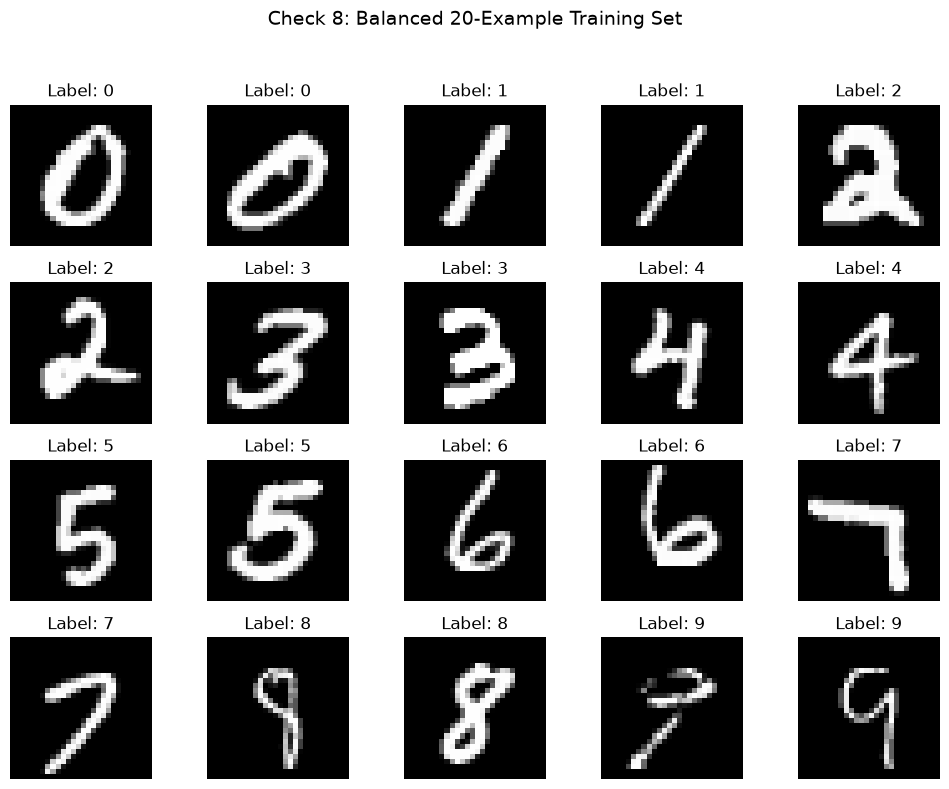

Saved: output/correctness_checks/check8_tiny_dataset.png


In [118]:
# ============================================================
# Display the 20-example tiny dataset
# ============================================================

fig, axes = plt.subplots(
    4,
    5,
    figsize=(10, 8)
)


axes = axes.ravel()


for plot_index, (
    image,
    label
) in enumerate(
    zip(check8_X, check8_y)
):

    axes[plot_index].imshow(
        image.reshape(28, 28),
        cmap="gray"
    )

    axes[plot_index].set_title(
        f"Label: {label}"
    )

    axes[plot_index].axis("off")


fig.suptitle(
    "Check 8: Balanced 20-Example Training Set",
    fontsize=14
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


check8_examples_path = (
    CHECK_OUTPUT_DIR
    / "check8_tiny_dataset.png"
)


fig.savefig(
    check8_examples_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


print(
    "Saved:",
    check8_examples_path
)

In [119]:
# ============================================================
# Full-batch tiny-overfitting procedure
# ============================================================

def check8_overfit_tiny_batch(
    X,
    y,
    hidden_size=128,
    activation="relu",
    initialization="he",
    learning_rate=0.5,
    maximum_steps=500,
    target_loss=1e-3,
    seed=SPLIT_SEED
):
    """
    Repeatedly train on the same complete tiny batch.

    Step 0 is measured before any parameter update.
    """

    parameters = initialize_parameters(
        input_size=X.shape[1],
        hidden_size=hidden_size,
        output_size=10,
        initialization=initialization,
        seed=seed
    )

    history = {
        "step": [],
        "loss": [],
        "accuracy": [],
        "global_gradient_norm": []
    }

    success = False
    success_step = None
    failure_reason = ""

    for step in range(
        maximum_steps + 1
    ):

        # ----------------------------------------------
        # Forward propagation
        # ----------------------------------------------

        probabilities, cache = forward_pass(
            X=X,
            parameters=parameters,
            activation=activation
        )

        loss = cross_entropy_loss(
            cache["logits"],
            y
        )

        predictions = np.argmax(
            probabilities,
            axis=1
        )

        accuracy = np.mean(
            predictions == y
        )

        # ----------------------------------------------
        # Stop if the loss is invalid
        # ----------------------------------------------

        if not np.isfinite(loss):

            failure_reason = (
                f"Non-finite loss at step {step}"
            )

            break

        # ----------------------------------------------
        # Manual backpropagation
        # ----------------------------------------------

        gradients = backward_pass(
            y=y,
            parameters=parameters,
            cache=cache,
            activation=activation
        )

        gradients_are_finite = all(
            np.all(np.isfinite(gradient))
            for gradient
            in gradients.values()
        )

        if not gradients_are_finite:

            failure_reason = (
                "Non-finite gradient at "
                f"step {step}"
            )

            break

        global_gradient_norm = np.sqrt(
            sum(
                np.sum(
                    np.square(gradient)
                )
                for gradient
                in gradients.values()
            )
        )

        # Record measurements before the update
        history["step"].append(step)
        history["loss"].append(loss)
        history["accuracy"].append(
            accuracy
        )
        history[
            "global_gradient_norm"
        ].append(
            global_gradient_norm
        )

        # ----------------------------------------------
        # Check the PDF success criteria
        # ----------------------------------------------

        if (
            accuracy == 1.0
            and loss < target_loss
        ):

            success = True
            success_step = step

            break

        # Do not update after the final allowed step
        if step == maximum_steps:
            break

        # ----------------------------------------------
        # Full-batch parameter update
        # ----------------------------------------------

        parameters = update_parameters(
            parameters=parameters,
            gradients=gradients,
            learning_rate=learning_rate
        )

    if (
        not success
        and failure_reason == ""
    ):
        failure_reason = (
            "Target was not reached within "
            f"{maximum_steps} updates."
        )

    result = {
        "success": success,
        "success_step": success_step,
        "failure_reason": failure_reason,
        "final_loss": history["loss"][-1],
        "final_accuracy": (
            history["accuracy"][-1]
        ),
        "steps_recorded": len(
            history["step"]
        )
    }

    return parameters, history, result

In [120]:
# ============================================================
# Run the tiny-batch overfitting test
# ============================================================

CHECK8_HIDDEN_SIZE = 128
CHECK8_ACTIVATION = "relu"
CHECK8_INITIALIZATION = "he"
CHECK8_LEARNING_RATE = 0.5
CHECK8_MAXIMUM_STEPS = 500
CHECK8_TARGET_LOSS = 1e-3
CHECK8_SEED = SPLIT_SEED


(
    check8_final_parameters,
    check8_history,
    check8_result
) = check8_overfit_tiny_batch(
    X=check8_X,
    y=check8_y,
    hidden_size=CHECK8_HIDDEN_SIZE,
    activation=CHECK8_ACTIVATION,
    initialization=CHECK8_INITIALIZATION,
    learning_rate=CHECK8_LEARNING_RATE,
    maximum_steps=CHECK8_MAXIMUM_STEPS,
    target_loss=CHECK8_TARGET_LOSS,
    seed=CHECK8_SEED
)


print("=" * 70)
print("TINY-BATCH OVERFITTING RESULT")
print("=" * 70)

print(
    "Success:",
    check8_result["success"]
)

print(
    "Success step:",
    check8_result["success_step"]
)

print(
    "Initial loss:",
    check8_history["loss"][0]
)

print(
    "Initial accuracy:",
    check8_history["accuracy"][0]
)

print(
    "Final loss:",
    check8_result["final_loss"]
)

print(
    "Final accuracy:",
    check8_result["final_accuracy"]
)

print(
    "Failure reason:",
    (
        check8_result["failure_reason"]
        if not check8_result["success"]
        else "None"
    )
)

TINY-BATCH OVERFITTING RESULT
Success: True
Success step: 250
Initial loss: 2.371450052162514
Initial accuracy: 0.05
Final loss: 0.000999775145748438
Final accuracy: 1.0
Failure reason: None


In [121]:
# ============================================================
# Verify the final predictions
# ============================================================

(
    check8_final_probabilities,
    check8_final_cache
) = forward_pass(
    X=check8_X,
    parameters=check8_final_parameters,
    activation=CHECK8_ACTIVATION
)


check8_final_predictions = np.argmax(
    check8_final_probabilities,
    axis=1
)


check8_prediction_df = pd.DataFrame({
    "Example": np.arange(
        len(check8_y)
    ),
    "True Label": check8_y,
    "Final Prediction": (
        check8_final_predictions
    ),
    "Correct": (
        check8_final_predictions
        == check8_y
    ),
    "Correct-Class Probability": (
        check8_final_probabilities[
            np.arange(len(check8_y)),
            check8_y
        ]
    )
})


display(check8_prediction_df)


print(
    "Number correct:",
    np.sum(
        check8_final_predictions
        == check8_y
    ),
    "/",
    len(check8_y)
)

,Example,True Label,Final Prediction,Correct,Correct-Class Probability
0,0,0,0,True,0.999042
1,1,0,0,True,0.999636
2,2,1,1,True,0.999515
3,3,1,1,True,0.998561
4,4,2,2,True,0.999512
5,5,2,2,True,0.999223
6,6,3,3,True,0.999128
7,7,3,3,True,0.999052
8,8,4,4,True,0.999150
9,9,4,4,True,0.999126


Number correct: 20 / 20


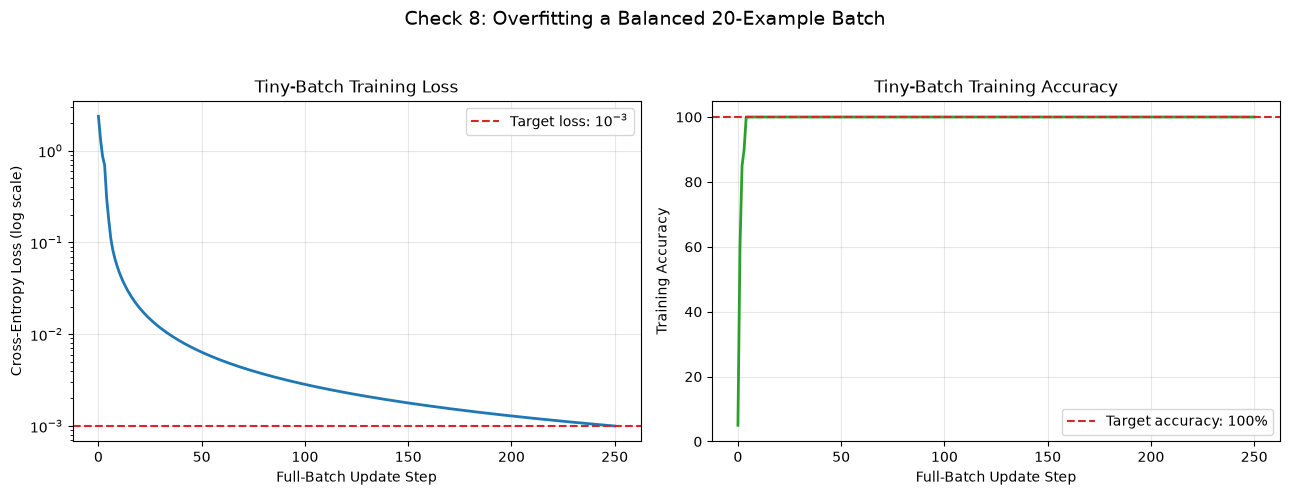

Saved: output/correctness_checks/check8_tiny_batch_overfitting.png


In [122]:
# ============================================================
# Plot loss and accuracy over update steps
# ============================================================

check8_steps = np.array(
    check8_history["step"]
)

check8_losses = np.array(
    check8_history["loss"]
)

check8_accuracies = np.array(
    check8_history["accuracy"]
)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


# Loss curve
axes[0].plot(
    check8_steps,
    check8_losses,
    color="tab:blue",
    linewidth=2
)

axes[0].axhline(
    CHECK8_TARGET_LOSS,
    color="tab:red",
    linestyle="--",
    label=r"Target loss: $10^{-3}$"
)

axes[0].set_yscale("log")
axes[0].set_title(
    "Tiny-Batch Training Loss"
)
axes[0].set_xlabel(
    "Full-Batch Update Step"
)
axes[0].set_ylabel(
    "Cross-Entropy Loss (log scale)"
)
axes[0].grid(alpha=0.3)
axes[0].legend()


# Accuracy curve
axes[1].plot(
    check8_steps,
    100 * check8_accuracies,
    color="tab:green",
    linewidth=2
)

axes[1].axhline(
    100,
    color="tab:red",
    linestyle="--",
    label="Target accuracy: 100%"
)

axes[1].set_title(
    "Tiny-Batch Training Accuracy"
)
axes[1].set_xlabel(
    "Full-Batch Update Step"
)
axes[1].set_ylabel(
    "Training Accuracy"
)
axes[1].set_ylim(0, 105)
axes[1].grid(alpha=0.3)
axes[1].legend()


fig.suptitle(
    "Check 8: Overfitting a Balanced 20-Example Batch",
    fontsize=14
)


plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)


check8_curve_path = (
    CHECK_OUTPUT_DIR
    / "check8_tiny_batch_overfitting.png"
)


fig.savefig(
    check8_curve_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()
plt.close(fig)


print(
    "Saved:",
    check8_curve_path
)

In [123]:
# ============================================================
# Formal Check 8 summary
# ============================================================

check8_balanced_subset = np.array_equal(
    np.bincount(
        check8_y,
        minlength=10
    ),
    np.full(
        10,
        CHECK8_EXAMPLES_PER_CLASS
    )
)


check8_accuracy_passed = (
    check8_result["final_accuracy"]
    == 1.0
)


check8_loss_passed = (
    check8_result["final_loss"]
    < CHECK8_TARGET_LOSS
)


check8_step_passed = (
    check8_result["success_step"]
    is not None
    and check8_result["success_step"]
    <= CHECK8_MAXIMUM_STEPS
)


check8_summary_df = pd.DataFrame([
    {
        "Check": "Balanced 20-example subset",
        "Measured Value": (
            np.bincount(
                check8_y,
                minlength=10
            ).tolist()
        ),
        "Required Value": (
            "Two examples per class"
        ),
        "Status": (
            "PASS"
            if check8_balanced_subset
            else "FAIL"
        )
    },
    {
        "Check": "Final training accuracy",
        "Measured Value": (
            check8_result[
                "final_accuracy"
            ]
        ),
        "Required Value": 1.0,
        "Status": (
            "PASS"
            if check8_accuracy_passed
            else "FAIL"
        )
    },
    {
        "Check": "Final training loss",
        "Measured Value": (
            check8_result[
                "final_loss"
            ]
        ),
        "Required Value": "< 0.001",
        "Status": (
            "PASS"
            if check8_loss_passed
            else "FAIL"
        )
    },
    {
        "Check": "Update-step budget",
        "Measured Value": (
            check8_result[
                "success_step"
            ]
        ),
        "Required Value": (
            f"At most "
            f"{CHECK8_MAXIMUM_STEPS}"
        ),
        "Status": (
            "PASS"
            if check8_step_passed
            else "FAIL"
        )
    }
])


display(check8_summary_df)


check8_overall_passed = (
    check8_summary_df["Status"]
    .eq("PASS")
    .all()
)


print("=" * 70)
print("CHECK 8: TINY-BATCH OVERFITTING")
print("=" * 70)

print(
    "Initial loss:",
    check8_history["loss"][0]
)

print(
    "Final loss:",
    check8_result["final_loss"]
)

print(
    "Final accuracy:",
    (
        f"{100 * check8_result['final_accuracy']:.2f}%"
    )
)

print(
    "Success step:",
    check8_result["success_step"]
)

print(
    "OVERALL STATUS:",
    (
        "PASS"
        if check8_overall_passed
        else "FAIL"
    )
)

,Check,Measured Value,Required Value,Status
0,Balanced 20-example subset,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]",Two examples per class,PASS
1,Final training accuracy,1.0,1.0,PASS
2,Final training loss,0.001,< 0.001,PASS
3,Update-step budget,250,At most 500,PASS


CHECK 8: TINY-BATCH OVERFITTING
Initial loss: 2.371450052162514
Final loss: 0.000999775145748438
Final accuracy: 100.00%
Success step: 250
OVERALL STATUS: PASS


In [124]:
# ============================================================
# Save Check 8 results
# ============================================================

check8_history_df = pd.DataFrame({
    "step": check8_history["step"],
    "loss": check8_history["loss"],
    "accuracy": (
        check8_history["accuracy"]
    ),
    "global_gradient_norm": (
        check8_history[
            "global_gradient_norm"
        ]
    )
})


check8_history_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check8_tiny_batch_history.csv",
    index=False
)

check8_prediction_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check8_final_predictions.csv",
    index=False
)

check8_summary_df.to_csv(
    CHECK_OUTPUT_DIR
    / "check8_tiny_batch_summary.csv",
    index=False
)


print(
    "Saved tiny-batch evidence in:",
    CHECK_OUTPUT_DIR
)

Saved tiny-batch evidence in: output/correctness_checks
